In [4]:
%%writefile /home/jovyan/work/scripts/database_checker.py

import numpy as np
import pandas as pd
import os
from pathlib import Path
from dotenv import load_dotenv
import re
import platform
import pymssql  # вместо pyodbc

# Загружаем переменные из .env файла
load_dotenv('/home/jovyan/work/.env')

class DatabaseChecker:
    """Класс для изъятия цен на прошедшие продажи из БД"""
    
    def __init__(self, use_sa_login=True):
        """
        use_sa_login: если True, использует SQL-логин (sa)
                     если False, использует доменную аутентификацию (только для Windows)
        """
        # Определяем, где мы запущены
        self.is_windows = platform.system() == 'Windows'
        self.is_linux = platform.system() == 'Linux'
        
        # Берем настройки из .env или используем значения по умолчанию
        self.db_host = os.getenv("DB_HOST", "172.16.0.108")
        self.db_name = os.getenv("DB_NAME", "ВитринаДанных")
        
        if self.is_linux or use_sa_login:
            # В контейнере используем SQL-логин (sa)
            self.db_user = os.getenv("DB_USER", "sa")
            self.db_password = os.getenv("DB_PASSWORD", "sasa")
            self.auth_type = "SQL логин"
        else:
            # На Windows (локально) оставляем доменную аутентификацию
            self.db_user = None
            self.db_password = None
            self.auth_type = "Windows аутентификация"
        
        print(f" Подключение через {self.auth_type}")
        print(f"   Сервер: {self.db_host}/{self.db_name}")
        if self.db_user:
            print(f"   Пользователь: {self.db_user}")
        
        # Не создаём engine заранее, будем создавать подключение при каждом запросе
        self.connection = None
    
    def get_connection(self):
        """Создаёт подключение к БД"""
        if self.is_windows and not self.db_user:
            # Для Windows с доменной аутентификацией
            import pyodbc
            conn_str = (
                f"DRIVER={os.getenv('DB_DRIVER', 'SQL Server')};"
                f"SERVER={self.db_host};"
                f"DATABASE={self.db_name};"
                f"Trusted_Connection=yes;"
            )
            return pyodbc.connect(conn_str)
        else:
            # Для Linux или SQL-логина
            return pymssql.connect(
                server=self.db_host,
                user=self.db_user,
                password=self.db_password,
                database=self.db_name,
                timeout=10,
                charset='UTF-8'  # Важно для кириллицы
            )
    
    def get_sales_data(self, name=None) -> pd.DataFrame:
        """Получает данные по продажам для указанной номенклатуры"""
        
        if name is None:
            name = input("Название номенклатуры: ")
        
        try:
            # Ваш оригинальный запрос (немного адаптирован для pymssql)
            query = """
            SELECT nomenklatura._Description as [Номенклатура],
                DATEADD(year, -2000, [Дата]) as [Дата],
                [Количество],
                [Цена],
                [Сумма],
                [НДС],
                kontrag._Description as [Контрагент],
                organ._Description as [Организация]
            FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
            inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
                on nomenklatura._Idrref=vypuskProduktNakoplenie.[НоменклатураИД]
            left join [onec-9].upp_2012.dbo._Reference124 as kontrag
                on kontrag._Idrref=vypuskProduktNakoplenie.[КонтрагентИД]
            left join [onec-9].upp_2012.dbo._Reference164 as organ
                on organ._Idrref=vypuskProduktNakoplenie.[ОрганизацияИД]
            WHERE nomenklatura._Description = %s
            ORDER BY [Дата] DESC
            """
            
            # Создаём подключение
            conn = self.get_connection()
            
            # Выполняем запрос через pandas
            df = pd.read_sql(query, conn, params=(name,))
            
            # Закрываем подключение
            conn.close()
            
            if len(df) > 0:
                print(f"\n Найдено {len(df)} записей для '{name}'")
                print(f"   Период: с {df['Дата'].min()} по {df['Дата'].max()}")
                return df
            else:
                print(f" Нет данных для '{name}'")
                return pd.DataFrame()
                
        except Exception as e:
            print(f" Ошибка запроса: {e}")
            return pd.DataFrame()
    
    def save_to_csv(self, df: pd.DataFrame, filename: str = None) -> str:
        """Сохраняет DataFrame в CSV с безопасным именем"""
        if df.empty:
            print(" Нет данных для сохранения")
            return None
        
        if filename is None:
            # Очищаем название от недопустимых символов
            item_name = df['Номенклатура'].iloc[0] if not df.empty else "data"
            safe_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', item_name)
            safe_name = safe_name[:50]
            # Сохраняем в папку data, которая примонтирована
            filename = f"/home/jovyan/work/data/raw/{safe_name}_sales_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"
        
        # Создаем папку, если её нет
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        
        df.to_csv(filename, index=False, sep=';', encoding='utf-8-sig')
        abs_path = os.path.abspath(filename)
        print(f"\n Данные сохранены в файл: {filename}")
        print(f"   Путь: {abs_path}")
        return filename

Overwriting /home/jovyan/work/scripts/database_checker.py


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import io
import json
from scipy import stats
from minio import Minio
from io import BytesIO

# ============================================
# ФУНКЦИЯ СОХРАНЕНИЯ В MINIO (ИСПРАВЛЕННАЯ)
# ============================================

def save_to_minio(
    bucket_name="sales-analytics", 
    block_name="анализ_продаж", 
    data=None, 
    plot_name=None, 
    fig=None, 
    dpi=150, 
    formats=['png'],
    excel_data=None
):
    """
    Сохраняет данные в Minio
    """
    print(f"\n Сохраняем в Minio: {bucket_name}/{block_name}")
    
    # Подключение к Minio
    minio_endpoint = "host.docker.internal:9002"
    minio_access = "minioadmin"
    minio_secret = "minioadmin"
    
    try:
        client = Minio(
            endpoint=minio_endpoint,
            access_key=minio_access,
            secret_key=minio_secret,
            secure=False
        )
        
        # Проверяем/создаём бакет
        if not client.bucket_exists(bucket_name):
            client.make_bucket(bucket_name)
            print(f" Создан бакет: {bucket_name}")
        
        # Очищаем имя блока
        clean_block = re.sub(r'[<>:"/\\|?*%\'"]', '_', block_name)
        clean_block = clean_block[:50]
        
        # Формируем путь
        current_date = datetime.now().strftime('%Y-%m-%d')
        base_path = f"{current_date}/{clean_block}"
        
        saved_objects = []
        
        # 1. СОХРАНЯЕМ CSV
        if data is not None:
            csv_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"data_{datetime.now().strftime('%Y%m%d_%H%M')}"
            csv_name = csv_name[:100]
            
            csv_buffer = io.StringIO()
            data.to_csv(csv_buffer, index=False, sep=';', encoding='utf-8-sig')
            csv_bytes = csv_buffer.getvalue().encode('utf-8-sig')
            
            object_path = f"{base_path}/{csv_name}.csv"
            client.put_object(
                bucket_name,
                object_path,
                data=BytesIO(csv_bytes),
                length=len(csv_bytes),
                content_type='text/csv; charset=utf-8'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" CSV: {file_url}")
            saved_objects.append(file_url)
        
        # 2. СОХРАНЯЕМ EXCEL
        if excel_data is not None:
            excel_name = f"stats_{datetime.now().strftime('%Y%m%d_%H%M')}.xlsx"
            
            excel_buffer = io.BytesIO()
            with pd.ExcelWriter(excel_buffer, engine='openpyxl') as writer:
                for sheet_name, sheet_data in excel_data.items():
                    sheet_data.to_excel(writer, sheet_name=sheet_name)
            excel_buffer.seek(0)
            
            object_path = f"{base_path}/{excel_name}"
            client.put_object(
                bucket_name,
                object_path,
                data=excel_buffer,
                length=excel_buffer.getbuffer().nbytes,
                content_type='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" Excel: {file_url}")
            saved_objects.append(file_url)
        
        # 3. СОХРАНЯЕМ ГРАФИКИ (раздельная логика для разных форматов)
        if fig is not None:
            clean_plot = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"plot_{datetime.now().strftime('%Y%m%d_%H%M')}"
            clean_plot = clean_plot[:100]
            
            for fmt in formats:
                img_buffer = io.BytesIO()
                
                try:
                    if fmt == 'pdf':
                        # Для PDF не используем fonttype
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    elif fmt == 'svg':
                        # Для SVG тоже особые настройки не нужны
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    else:
                        # Для PNG и других растровых форматов
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt, 
                                  pil_kwargs={'optimize': True})
                    
                    img_buffer.seek(0)
                    
                    object_path = f"{base_path}/{clean_plot}.{fmt}"
                    client.put_object(
                        bucket_name,
                        object_path,
                        data=img_buffer,
                        length=img_buffer.getbuffer().nbytes,
                        content_type=f'image/{fmt}'
                    )
                    
                    file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
                    print(f" {fmt.upper()}: {file_url}")
                    saved_objects.append(file_url)
                    
                except Exception as e:
                    print(f" Ошибка при сохранении {fmt}: {e}")
                    continue
        
        print(f"    Всего сохранено: {len(saved_objects)} объектов")
        return saved_objects
        
    except Exception as e:
        print(f" Ошибка при сохранении в Minio: {e}")
        import traceback
        traceback.print_exc()
        return []

In [6]:
from database_checker import DatabaseChecker
# Пример использования
checker = DatabaseChecker()
# Пример использования:
# 1. Получаем данные
df = checker.get_sales_data('Пр.из творога "365 дней" 24%.500г.пакет.8шт')  # указать нужное название

# 2. Если данные есть, работаем с ними
if not df.empty:
    print("\n Первые 5 строк данных:")
    print(df.head())

    print("\n Информация о данных:")
    print(df.info())

    print("\n Статистика по числовым колонкам:")
    print(df[['Количество', 'Цена', 'Сумма', 'НДС', 'Контрагент', 'Организация']].describe())

    # 3. Сохраняем в CSV
    checker.save_to_csv(df)

    # 4. Дополнительный анализ
    # Например, сгруппировать по месяцам:
    df['Дата'] = pd.to_datetime(df['Дата'])
    df['Месяц'] = df['Дата'].dt.to_period('M')
    monthly_sum = df.groupby('Месяц')['Сумма'].sum()
    print("\n Продажи по месяцам:")
    print(monthly_sum)
else:
    print("\nНет данных для анализа")

 Подключение через SQL логин
   Сервер: 172.16.0.108/ВитринаДанных
   Пользователь: sa


/home/jovyan/work/scripts/database_checker.py:104: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(name,))



 Найдено 1429 записей для 'Пр.из творога "365 дней" 24%.500г.пакет.8шт'
   Период: с 2022-11-11 15:04:18 по 2026-03-06 00:05:28

 Первые 5 строк данных:
                                  Номенклатура                Дата  \
0  Пр.из творога "365 дней" 24%.500г.пакет.8шт 2026-03-06 00:05:28   
1  Пр.из творога "365 дней" 24%.500г.пакет.8шт 2026-03-03 23:59:57   
2  Пр.из творога "365 дней" 24%.500г.пакет.8шт 2026-03-03 18:42:43   
3  Пр.из творога "365 дней" 24%.500г.пакет.8шт 2026-02-27 23:59:57   
4  Пр.из творога "365 дней" 24%.500г.пакет.8шт 2026-02-27 21:27:18   

   Количество    Цена     Сумма       НДС           Контрагент  \
0       648.0  162.53  52659.20   9495.92  Лента ООО РЦ Лешино   
1       448.0  148.40  33241.60   5994.39            ВРА-М ООО   
2       448.0  158.01  35395.23   6382.75   Лента ООО РЦ Ижора   
3       744.0  148.40  55204.80   9954.96            ВРА-М ООО   
4       744.0  162.53  60460.56  10902.72  Лента ООО РЦ Лешино   

           Организация  
0  

/home/jovyan/work/scripts/database_checker.py:104: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(name,))



 Найдено 1429 записей для 'Пр.из творога "365 дней" 24%.500г.пакет.8шт'
   Период: с 2022-11-11 15:04:18 по 2026-03-06 00:05:28

СТАТИСТИКА ПО КОНТРАГЕНТАМ (МАГАЗИНАМ)
                            Количество                              Сумма  \
                                   sum    mean     std count          sum   
Контрагент                                                                  
ВРА-М ООО                     224496.0  409.66  374.82   548  15181287.60   
Лента ООО РЦ Ижора             47448.0  287.56  142.52   165   3569222.93   
Лента ООО РЦ Лешино            44944.0  325.68  159.03   138   3439245.54   
Лента ООО РЦ Екатеринбург      37296.0  336.00  166.15   111   2898196.90   
Лента ООО РЦ Новосибирск       26120.0  318.54  200.95    82   2663938.38   
Лента ООО РЦ Тольятти          30464.0  200.42  200.10   152   2257004.46   
Лента ООО РЦ Ростов            26616.0  177.44  179.89   150   1973582.34   
Лента ООО РЦ Валищево           7520.0  313.33  281.14    24 

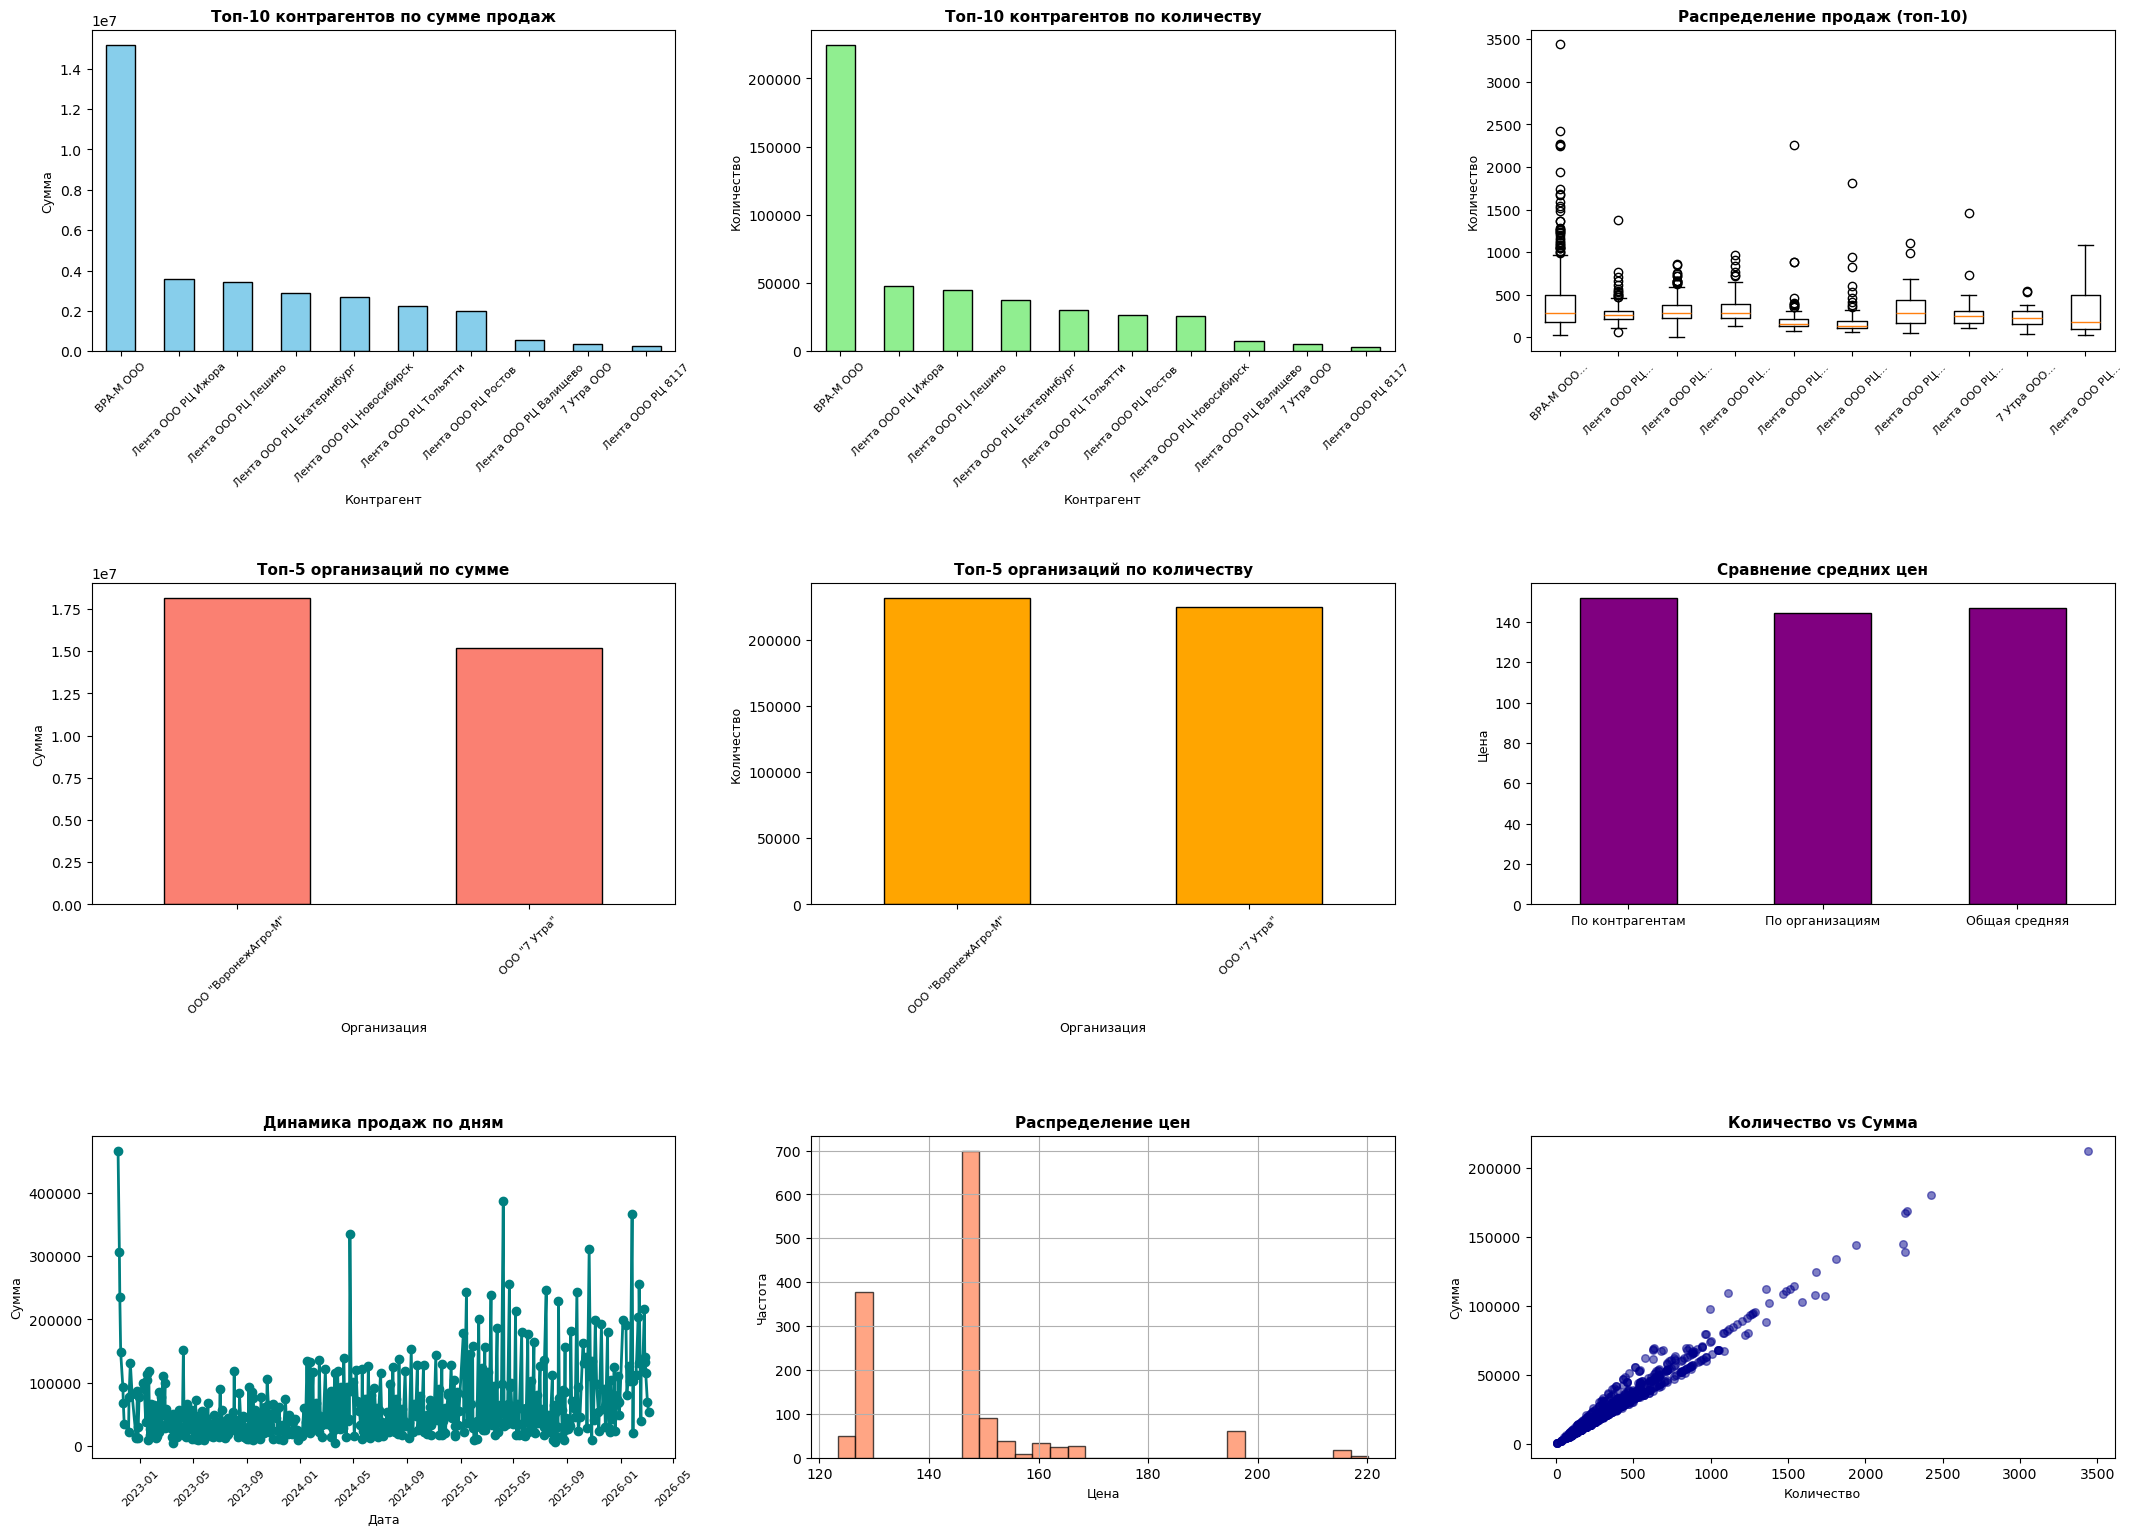


СВЯЗЬ ОРГАНИЗАЦИЙ И КОНТРАГЕНТОВ
Матрица связей (организации × контрагенты):
Контрагент           7 Утра ООО  ВРА-М ООО  Лента ООО РЦ 8024  \
Организация                                                     
ООО "7 Утра"                  0        548                  0   
ООО "ВоронежАгро-М"          21          0                 12   

Контрагент           Лента ООО РЦ 8117  Лента ООО РЦ 8130 - Воронеж  \
Организация                                                           
ООО "7 Утра"                         0                            0   
ООО "ВоронежАгро-М"                 10                            2   

Контрагент           Лента ООО РЦ 8143  Лента ООО РЦ Валищево  \
Организация                                                     
ООО "7 Утра"                         0                      0   
ООО "ВоронежАгро-М"                 14                     24   

Контрагент           Лента ООО РЦ Екатеринбург  Лента ООО РЦ Ижора  \
Организация                                  

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import io
import json
from scipy import stats
from minio import Minio
from io import BytesIO


# ============================================
# ОСНОВНОЙ АНАЛИЗ
# ============================================

# Получаем данные
df = checker.get_sales_data('Пр.из творога "365 дней" 24%.500г.пакет.8шт')

if not df.empty:
    # 1. АНАЛИЗ ПО КОНТРАГЕНТАМ (магазины)
    print("\n" + "="*60)
    print("СТАТИСТИКА ПО КОНТРАГЕНТАМ (МАГАЗИНАМ)")
    print("="*60)
    
    kontragent_stats = df.groupby('Контрагент').agg({
        'Количество': ['sum', 'mean', 'std', 'count'],
        'Сумма': ['sum', 'mean'],
        'Цена': 'mean'
    }).round(2)
    
    kontragent_stats = kontragent_stats.sort_values(('Сумма', 'sum'), ascending=False)
    print(kontragent_stats.head(15))
    
    # 2. АНАЛИЗ ПО ОРГАНИЗАЦИЯМ
    print("\n" + "="*60)
    print("СТАТИСТИКА ПО ОРГАНИЗАЦИЯМ")
    print("="*60)
    
    org_stats = df.groupby('Организация').agg({
        'Количество': ['sum', 'mean', 'std', 'count'],
        'Сумма': ['sum', 'mean'],
        'Цена': 'mean'
    }).round(2)
    
    org_stats = org_stats.sort_values(('Сумма', 'sum'), ascending=False)
    print(org_stats)
    
    # 3. ВИЗУАЛИЗАЦИЯ
 # СОЗДАЁМ ФИГУРУ ЯВНО
    fig = plt.figure(figsize=(22, 16))
    
    # 3.1 Топ-10 контрагентов по сумме
    ax1 = plt.subplot(3, 3, 1)
    top_kontragents_sum = df.groupby('Контрагент')['Сумма'].sum().nlargest(10)
    top_kontragents_sum.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax1)
    ax1.set_title('Топ-10 контрагентов по сумме продаж', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Контрагент', fontsize=9)
    ax1.set_ylabel('Сумма', fontsize=9)
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3.2 Топ-10 контрагентов по количеству
    ax2 = plt.subplot(3, 3, 2)
    top_kontragents_qty = df.groupby('Контрагент')['Количество'].sum().nlargest(10)
    top_kontragents_qty.plot(kind='bar', color='lightgreen', edgecolor='black', ax=ax2)
    ax2.set_title('Топ-10 контрагентов по количеству', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Контрагент', fontsize=9)
    ax2.set_ylabel('Количество', fontsize=9)
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3.3 Boxplot контрагентов
    ax3 = plt.subplot(3, 3, 3)
    top_kontragents_list = df.groupby('Контрагент')['Количество'].sum().nlargest(10).index
    df_top_kontr = df[df['Контрагент'].isin(top_kontragents_list)]
    box_data = [df_top_kontr[df_top_kontr['Контрагент'] == k]['Количество'].values for k in top_kontragents_list]
    ax3.boxplot(box_data, labels=[k[:12] + '...' for k in top_kontragents_list])
    ax3.set_title('Распределение продаж (топ-10)', fontsize=11, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45, labelsize=8)
    ax3.set_ylabel('Количество', fontsize=9)
    
    # 3.4 Топ-5 организаций по сумме
    ax4 = plt.subplot(3, 3, 4)
    top_orgs_sum = df.groupby('Организация')['Сумма'].sum().nlargest(5)
    top_orgs_sum.plot(kind='bar', color='salmon', edgecolor='black', ax=ax4)
    ax4.set_title('Топ-5 организаций по сумме', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Организация', fontsize=9)
    ax4.set_ylabel('Сумма', fontsize=9)
    ax4.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3.5 Топ-5 организаций по количеству
    ax5 = plt.subplot(3, 3, 5)
    top_orgs_qty = df.groupby('Организация')['Количество'].sum().nlargest(5)
    top_orgs_qty.plot(kind='bar', color='orange', edgecolor='black', ax=ax5)
    ax5.set_title('Топ-5 организаций по количеству', fontsize=11, fontweight='bold')
    ax5.set_xlabel('Организация', fontsize=9)
    ax5.set_ylabel('Количество', fontsize=9)
    ax5.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3.6 Сравнение средней цены
    ax6 = plt.subplot(3, 3, 6)
    avg_price = pd.DataFrame({
        'По контрагентам': df.groupby('Контрагент')['Цена'].mean().mean(),
        'По организациям': df.groupby('Организация')['Цена'].mean().mean(),
        'Общая средняя': df['Цена'].mean()
    }, index=['Средняя цена'])
    avg_price.T.plot(kind='bar', color='purple', edgecolor='black', legend=False, ax=ax6)
    ax6.set_title('Сравнение средних цен', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Цена', fontsize=9)
    ax6.set_xticklabels(ax6.get_xticklabels(), rotation=0, fontsize=9)
    
    # 3.7 Динамика продаж по дням
    ax7 = plt.subplot(3, 3, 7)
    df['Дата'] = pd.to_datetime(df['Дата'])
    daily_sales = df.groupby(df['Дата'].dt.date)['Сумма'].sum()
    daily_sales.plot(kind='line', marker='o', color='teal', linewidth=2, ax=ax7)
    ax7.set_title('Динамика продаж по дням', fontsize=11, fontweight='bold')
    ax7.set_xlabel('Дата', fontsize=9)
    ax7.set_ylabel('Сумма', fontsize=9)
    ax7.tick_params(axis='x', rotation=45, labelsize=8)
    
    # 3.8 Распределение цен
    ax8 = plt.subplot(3, 3, 8)
    df['Цена'].hist(bins=30, color='coral', edgecolor='black', alpha=0.7, ax=ax8)
    ax8.set_title('Распределение цен', fontsize=11, fontweight='bold')
    ax8.set_xlabel('Цена', fontsize=9)
    ax8.set_ylabel('Частота', fontsize=9)
    
    # 3.9 Связь количества и суммы
    ax9 = plt.subplot(3, 3, 9)
    ax9.scatter(df['Количество'], df['Сумма'], alpha=0.5, color='darkblue', s=30)
    ax9.set_title('Количество vs Сумма', fontsize=11, fontweight='bold')
    ax9.set_xlabel('Количество', fontsize=9)
    ax9.set_ylabel('Сумма', fontsize=9)
    
    # Настраиваем отступы
    plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=4.0)
    plt.show()
    
    # ============================================
    # 4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: СВЯЗЬ ОРГАНИЗАЦИЙ И КОНТРАГЕНТОВ
    # ============================================
    print("\n" + "="*60)
    print("СВЯЗЬ ОРГАНИЗАЦИЙ И КОНТРАГЕНТОВ")
    print("="*60)
    
    # Смотрим, какие контрагенты работают с какими организациями
    org_kontr_cross = pd.crosstab(df['Организация'], df['Контрагент'])
    print("Матрица связей (организации × контрагенты):")
    print(org_kontr_cross)
    
    # ============================================
    # 5. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ
    # ============================================
    from scipy import stats
    
    print("\nСТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:")
    
    # Проверяем влияние организации
    org_groups = [group['Количество'].values for name, group in df.groupby('Организация') if len(group) > 5]
    if len(org_groups) > 1:
        f_stat, p_value = stats.f_oneway(*org_groups)
        print(f"   Влияние ОРГАНИЗАЦИИ: p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("    Организация значимо влияет на продажи!")
        else:
            print("    Организация НЕ влияет значимо")
    
    # Проверяем влияние контрагента
    kontr_groups = [group['Количество'].values for name, group in df.groupby('Контрагент') if len(group) > 5]
    if len(kontr_groups) > 1:
        f_stat, p_value = stats.f_oneway(*kontr_groups)
        print(f"   Влияние КОНТРАГЕНТА: p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("    Контрагент значимо влияет на продажи!")
        else:
            print("    Контрагент НЕ влияет значимо")
    
    # ============================================
    # 6. ПОДГОТОВКА ДАННЫХ ДЛЯ MINIO
    # ============================================
    print("\n" + "="*60)
    print("ПОДГОТОВКА ДАННЫХ ДЛЯ MINIO")
    print("="*60)
    
    # Собираем все статистики в словарь для Excel
    excel_data = {
        'Контрагенты': kontragent_stats,
        'Организации': org_stats,
        'Связи': org_kontr_cross,
        'Сырые_данные': df.head(100)
    }
    
    print(f" Подготовлено листов для Excel: {len(excel_data)}")
    
    # ============================================
    # 7. СОХРАНЕНИЕ В MINIO
    # ============================================
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В MINIO")
    print("="*60)
    
    save_to_minio(
        bucket_name="sales-analytics",
        block_name="творог_365_дней",
        data=df,
        plot_name="комплексный_анализ_творог",
        fig=fig,  # передаем созданную фигуру
        formats=['png', 'pdf'],
        excel_data=excel_data
    )

print("\n Все данные сохранены в Minio!")


In [10]:
import json
import pickle
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from minio import Minio
from io import BytesIO
import re

def save_datasets_to_minio(
    train_df, 
    test_df=None, 
    product_name=None,
    bucket_name="ml-datasets",
    version=None,
    split_info=None
):
    """
    Сохраняет train/test датасеты в Minio с правильной структурой
    
    Parameters:
    train_df, test_df: DataFrame
    product_name: название продукта
    bucket_name: бакет в Minio
    version: версия датасета (если None, создается автоматически)
    split_info: дополнительная информация о разделении
    """
    
    # Подключение к Minio
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    # Создаем бакет если нет
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    # Очищаем имя продукта для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Формируем версию
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Базовый путь
    base_path = f"datasets/{clean_name}/train_test_split"
    
    saved_files = []
    
    # 1. Сохраняем train как parquet (эффективнее csv)
    train_buffer = BytesIO()
    train_df.to_parquet(train_buffer, index=False)
    train_buffer.seek(0)
    
    train_path = f"{base_path}/train_{version}.parquet"
    client.put_object(
        bucket_name,
        train_path,
        data=train_buffer,
        length=train_buffer.getbuffer().nbytes,
        content_type='application/parquet'
    )
    saved_files.append(f"{bucket_name}/{train_path}")
    print(f" Train сохранен: {train_path}")
    
    # 2. Сохраняем test
    if test_df is not None:
        test_buffer = BytesIO()
        test_df.to_parquet(test_buffer, index=False)
        test_buffer.seek(0)
        
        test_path = f"{base_path}/test_{version}.parquet"
        client.put_object(
            bucket_name,
            test_path,
            data=test_buffer,
            length=test_buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
        saved_files.append(f"{bucket_name}/{test_path}")
        print(f" Test сохранен: {test_path}")
    
    # 3. Сохраняем метаданные о разделении
    if split_info is None:
        split_info = {
            'product': product_name,
            'version': version,
            'train_size': len(train_df),
            'test_size': len(test_df),
            'train_period': {
                'start': str(train_df['Дата'].min()),
                'end': str(train_df['Дата'].max())
            },
            'test_period': {
                'start': str(test_df['Дата'].min()),
                'end': str(test_df['Дата'].max())
            },
            'features': list(train_df.columns),
            'created_at': datetime.now().isoformat()
        }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(split_info, indent=2, ensure_ascii=False).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/split_info_{version}.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" Метаданные сохранены: {meta_path}")
    
    return {
        'train_path': train_path,
        'test_path': test_path,
        'meta_path': meta_path,
        'version': version,
        'bucket': bucket_name,
        'files': saved_files
    }


def load_datasets_from_minio(
    bucket_name="ml-datasets",
    product_name=None,
    version=None,
    latest=True
):
    """
    Загружает датасеты из Minio
    
    Если latest=True, берет последнюю версию
    Иначе нужно указать version
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    base_path = f"datasets/{clean_name}/train_test_split"
    
    if latest:
        # Находим последнюю версию
        objects = list(client.list_objects(bucket_name, prefix=base_path, recursive=True))
        versions = set()
        for obj in objects:
            if 'train_' in obj.object_name:
                ver = obj.object_name.split('train_')[-1].split('.parquet')[0]
                versions.add(ver)
        
        if not versions:
            raise ValueError(f"Нет датасетов для продукта {product_name}")
        
        version = sorted(versions)[-1]
        print(f"Загружаем последнюю версию: {version}")
    
    # Загружаем train
    train_path = f"{base_path}/train_{version}.parquet"
    train_response = client.get_object(bucket_name, train_path)
    train_df = pd.read_parquet(BytesIO(train_response.read()))
    
    # Загружаем test
    test_path = f"{base_path}/test_{version}.parquet"
    test_response = client.get_object(bucket_name, test_path)
    test_df = pd.read_parquet(BytesIO(test_response.read()))
    
    # Загружаем метаданные
    meta_path = f"{base_path}/split_info_{version}.json"
    try:
        meta_response = client.get_object(bucket_name, meta_path)
        meta_info = json.loads(meta_response.read().decode())
    except:
        meta_info = None
    
    print(f" Загружено: train={len(train_df)}, test={len(test_df)}")
    return train_df, test_df, meta_info


def save_features_to_minio(
    X_train, X_test, y_train, y_test,
    feature_names,
    product_name,
    version=None
):
    """
    Сохраняет признаки и целевые переменные для модели
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "ml-datasets"
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    base_path = f"features/{clean_name}/{version}"
    
    # Сохраняем признаки
    features_dict = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': feature_names
    }
    
    for name, data in features_dict.items():
        buffer = BytesIO()
        
        if isinstance(data, pd.DataFrame) or isinstance(data, pd.Series):
            data.to_parquet(buffer)
        elif isinstance(data, np.ndarray):
            pd.DataFrame(data).to_parquet(buffer)
        else:
            # для списков и простых типов
            buffer.write(json.dumps(data).encode())
            buffer.seek(0)
            client.put_object(
                bucket_name,
                f"{base_path}/{name}.json",
                data=buffer,
                length=buffer.getbuffer().nbytes,
                content_type='application/json'
            )
            continue
        
        buffer.seek(0)
        client.put_object(
            bucket_name,
            f"{base_path}/{name}.parquet",
            data=buffer,
            length=buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
    
    print(f" Признаки сохранены: {base_path}")

In [11]:
checker = DatabaseChecker()
df = checker.get_sales_data('Пр.из творога "365 дней" 24%.500г.пакет.8шт')

# Исправляем даты
df['Дата'] = pd.to_datetime(df['Дата'].astype(str).str.replace('402', '202'))

# Разделяем на train/test
today = datetime.now().date()
cutoff_date = today - timedelta(days=30)
print(f"Дата отсечки: {cutoff_date}")

train_df = df[df['Дата'].dt.date < cutoff_date].copy()
test_df = df[df['Дата'].dt.date >= cutoff_date].copy()

# СОХРАНЯЕМ В MINIO!
result = save_datasets_to_minio(
    train_df=train_df,
    test_df=test_df,
    product_name='творог_365_дней',
    split_info={
        'cutoff_date': str(cutoff_date),
        'split_method': 'last_30_days',
        'description': 'Train/test split для прогнозирования продаж'
    }
)

print(f"\n Датасеты сохранены:")
print(f"   Версия: {result['version']}")
print(f"   Путь: {result['train_path']}")

# Позже, когда понадобится загрузить:
# train_df, test_df, meta = load_datasets_from_minio(
#     product_name='творог_365_дней',
#     latest=True
# )

 Подключение через SQL логин
   Сервер: 172.16.0.108/ВитринаДанных
   Пользователь: sa


/home/jovyan/work/scripts/database_checker.py:104: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(name,))



 Найдено 1429 записей для 'Пр.из творога "365 дней" 24%.500г.пакет.8шт'
   Период: с 2022-11-11 15:04:18 по 2026-03-06 00:05:28
Дата отсечки: 2026-02-08
 Train сохранен: datasets/творог_365_дней/train_test_split/train_20260310_133818.parquet
 Test сохранен: datasets/творог_365_дней/train_test_split/test_20260310_133818.parquet
 Метаданные сохранены: datasets/творог_365_дней/train_test_split/split_info_20260310_133818.json

 Датасеты сохранены:
   Версия: 20260310_133818
   Путь: datasets/творог_365_дней/train_test_split/train_20260310_133818.parquet


 Анализ данных по продажам

 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Распределение количества продаж_20260310.pdf
    Всего сохранено: 1 объектов

АНАЛИЗ ПО ОРГАНИЗАЦИЯМ И КОНТРАГЕНТАМ

Статистика по организациям:
                    Количество                      Сумма
                           sum    mean count          sum
Организация                                              
ООО "ВоронежАгро-М"   231200.0  262.43   881  18149146.73
ООО "7 Утра"          224496.0  409.66   548  15181287.60

Статистика по контрагентам (топ-10):
                          Количество                      Сумма
                                 sum    mean count          sum
Контрагент                                                     
ВРА-М ООО                   224496.0  409.66   548  15181287.60
Лента ООО РЦ Ижора           47448.0  287.56   165   3569222.9

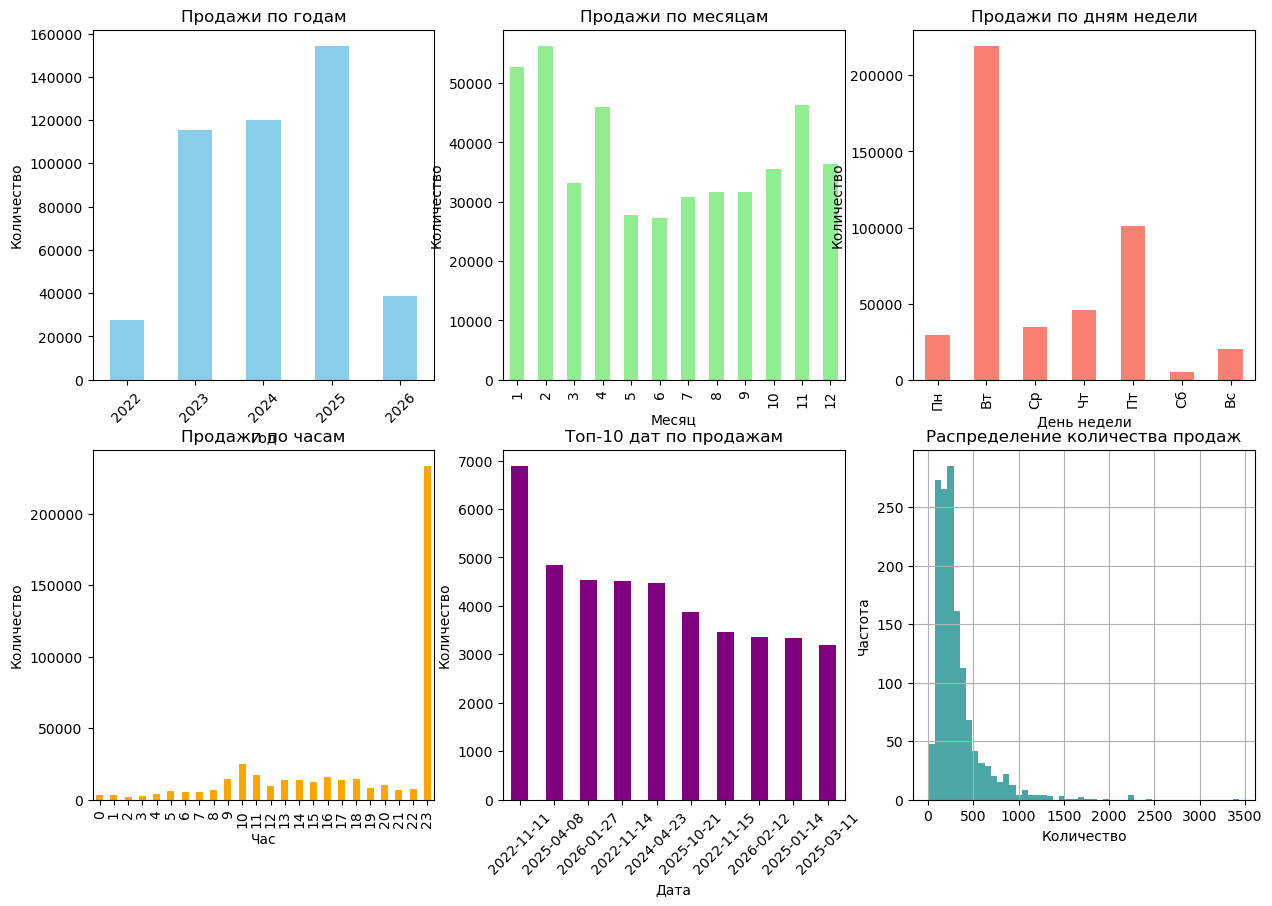

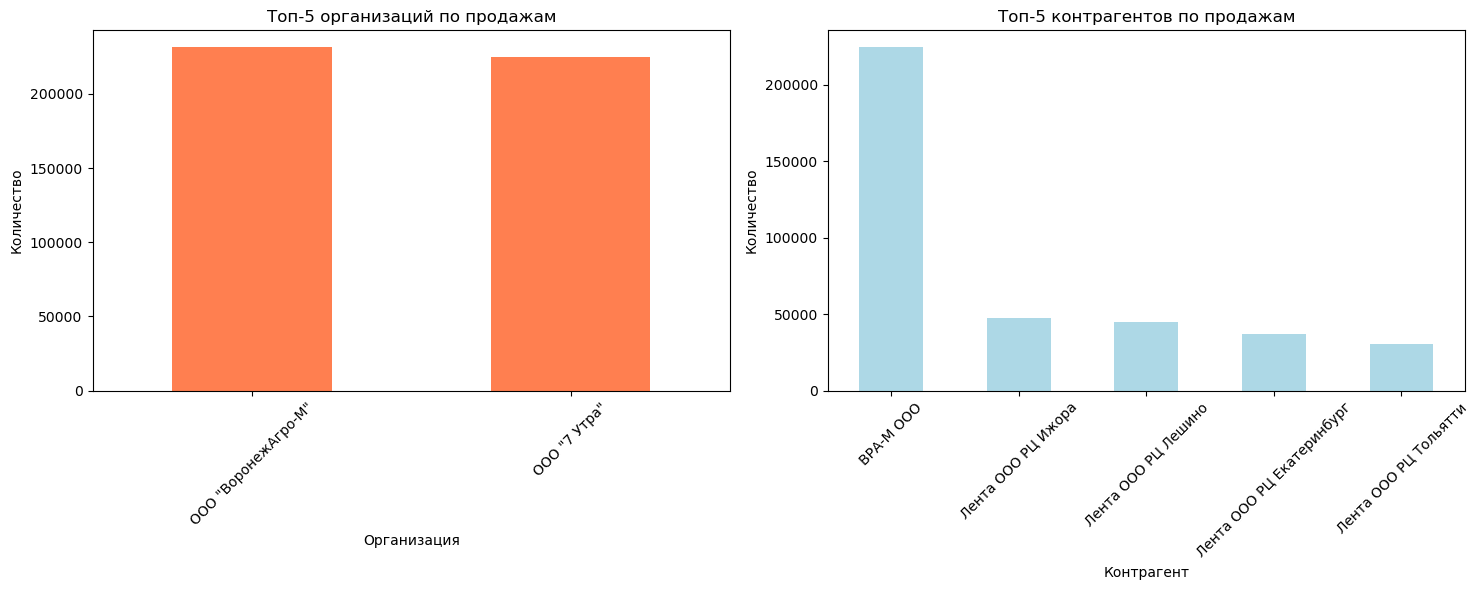


Анализ завершен. p-value = 0 подтверждает значимость этих признаков!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Исправляем даты перед анализом (4026 -> 2026)
df['Дата'] = pd.to_datetime(df['Дата'].astype(str).str.replace('402', '202'))

# Создаем дополнительные временные признаки для анализа
df['Год'] = df['Дата'].dt.year
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.dayofweek  # 0=понедельник, 6=воскресенье
df['Неделя'] = df['Дата'].dt.isocalendar().week
df['Час'] = df['Дата'].dt.hour
df['Дата_без_времени'] = df['Дата'].dt.date

print(" Анализ данных по продажам")
print("="*60)

# 1. Анализ продаж по времени
plt.figure(figsize=(15, 10))

# 1.1 Продажи по годам
plt.subplot(2, 3, 1)
sales_by_year = df.groupby('Год')['Количество'].sum()
sales_by_year.plot(kind='bar', color='skyblue')
plt.title('Продажи по годам')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.xticks(rotation=45)

# 1.2 Продажи по месяцам
plt.subplot(2, 3, 2)
sales_by_month = df.groupby('Месяц')['Количество'].sum()
sales_by_month.plot(kind='bar', color='lightgreen')
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')

# 1.3 Продажи по дням недели
plt.subplot(2, 3, 3)
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
sales_by_day = df.groupby('День_недели')['Количество'].sum()
sales_by_day.index = [days[i] for i in sales_by_day.index]
sales_by_day.plot(kind='bar', color='salmon')
plt.title('Продажи по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество')

# 1.4 Продажи по часам
plt.subplot(2, 3, 4)
sales_by_hour = df.groupby('Час')['Количество'].sum()
sales_by_hour.plot(kind='bar', color='orange')
plt.title('Продажи по часам')
plt.xlabel('Час')
plt.ylabel('Количество')

# 1.5 Топ-10 дат по продажам
plt.subplot(2, 3, 5)
top_dates = df.groupby('Дата_без_времени')['Количество'].sum().nlargest(10)
top_dates.plot(kind='bar', color='purple')
plt.title('Топ-10 дат по продажам')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=45)

# 1.6 Распределение размера продаж
plt.subplot(2, 3, 6)
df['Количество'].hist(bins=50, color='teal', alpha=0.7)
plt.title('Распределение количества продаж')
plt.xlabel('Количество')
plt.ylabel('Частота')

save_to_minio(
    bucket_name="sales-analytics",  # добавляем bucket
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Распределение количества продаж_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']  # только PDF
)
# ДОБАВЛЯЕМ АНАЛИЗ ПО ОРГАНИЗАЦИЯМ И КОНТРАГЕНТАМ
print("\n" + "="*60)
print("АНАЛИЗ ПО ОРГАНИЗАЦИЯМ И КОНТРАГЕНТАМ")
print("="*60)

# Статистика по организациям
org_stats = df.groupby('Организация').agg({
    'Количество': ['sum', 'mean', 'count'],
    'Сумма': 'sum'
}).round(2)
print("\nСтатистика по организациям:")
print(org_stats.sort_values(('Сумма', 'sum'), ascending=False))

# Статистика по контрагентам
kontr_stats = df.groupby('Контрагент').agg({
    'Количество': ['sum', 'mean', 'count'],
    'Сумма': 'sum'
}).round(2)
print("\nСтатистика по контрагентам (топ-10):")
print(kontr_stats.sort_values(('Сумма', 'sum'), ascending=False).head(10))

# Визуализация влияния организаций и контрагентов
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
top_orgs = df.groupby('Организация')['Количество'].sum().nlargest(5)
top_orgs.plot(kind='bar', color='coral')
plt.title('Топ-5 организаций по продажам')
plt.xlabel('Организация')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
top_kontr = df.groupby('Контрагент')['Количество'].sum().nlargest(5)
top_kontr.plot(kind='bar', color='lightblue')
plt.title('Топ-5 контрагентов по продажам')
plt.xlabel('Контрагент')
plt.ylabel('Количество')
plt.xticks(rotation=45)

save_to_minio(
    bucket_name="sales-analytics",  # добавляем bucket
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Топ-5 организаций по продажам_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']  # только PDF
)

plt.tight_layout()
plt.show()

print("\nАнализ завершен. p-value = 0 подтверждает значимость этих признаков!")


 Статистика продаж:
count    1429.000000
mean      318.891533
std       284.560741
min         8.000000
25%       152.000000
50%       240.000000
75%       368.000000
max      3440.000000
Name: Количество, dtype: float64

 Топ-10 самых больших продаж:
                    Дата  Количество    Цена      Сумма
1425 2022-11-11 23:59:57      3440.0  123.36  212179.20
349  2025-04-08 23:59:57      2424.0  148.40  179860.80
35   2026-01-27 23:59:57      2272.0  148.40  168582.40
1423 2022-11-14 23:59:57      2256.0  123.36  139150.08
1424 2022-11-14 17:55:43      2256.0  148.03  166980.10
755  2024-04-23 23:59:57      2240.0  129.22  144726.40
127  2025-10-21 23:59:57      1936.0  148.40  143651.20
1428 2022-11-11 15:04:18      1808.0  148.03  133820.93
1420 2022-11-15 23:59:57      1736.0  123.36  107076.48
18   2026-02-12 23:59:57      1680.0  148.40  124656.00

 Топ-10 самых маленьких продаж (не считая 0):
                    Дата  Количество    Цена    Сумма
46   2026-01-15 16:32:55      

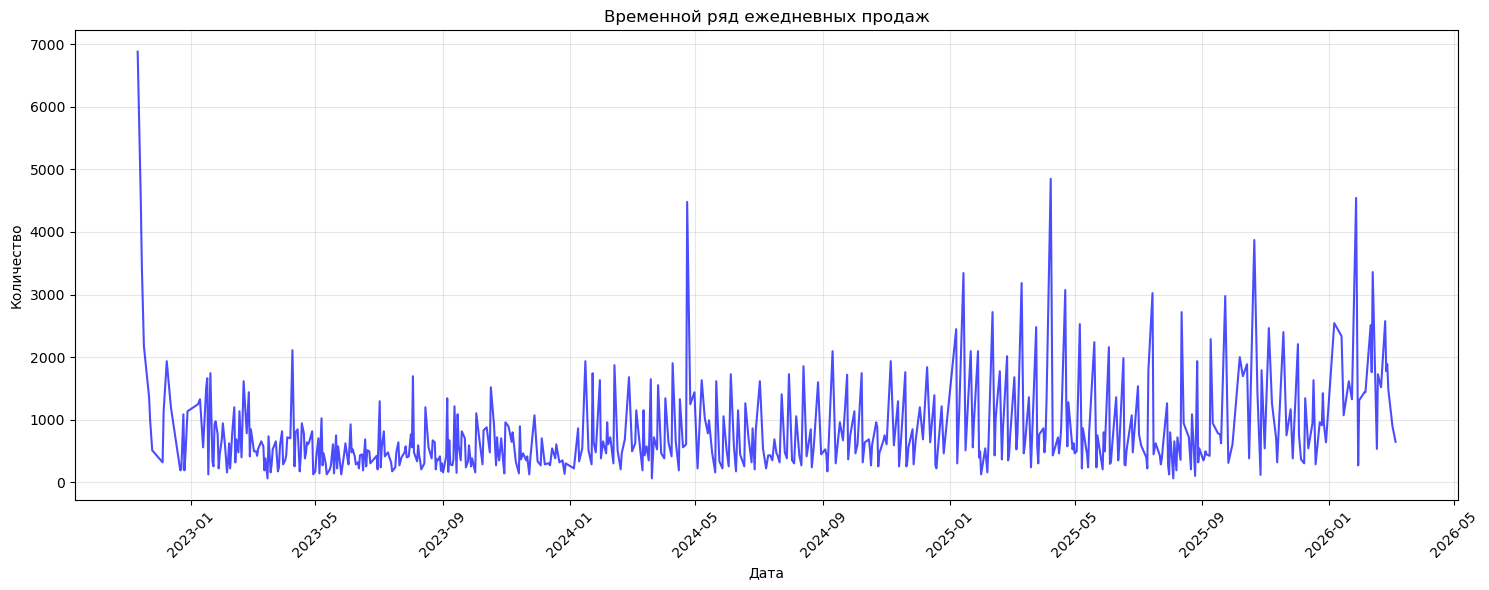


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Временной ряд со скользящим средним_20260310.pdf
    Всего сохранено: 1 объектов


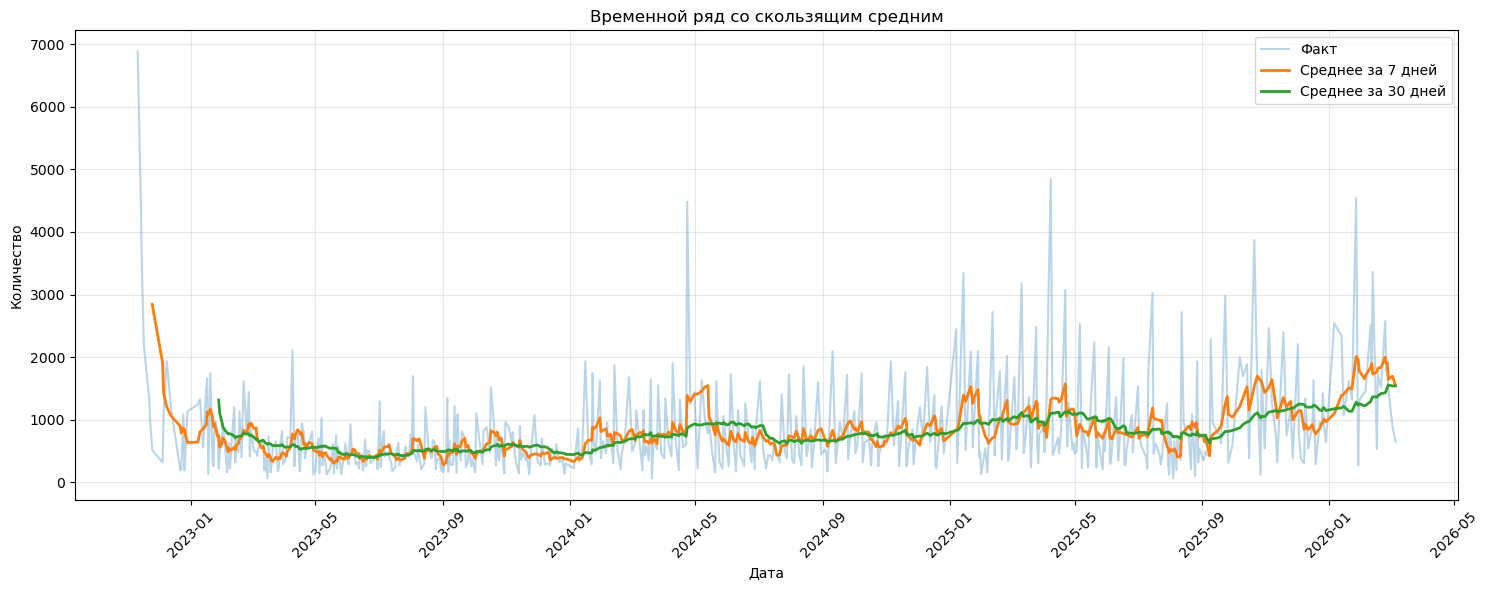

In [13]:
#  Статистика по продажам
print("\n Статистика продаж:")
print(df['Количество'].describe())

#  Анализ выбросов
print("\n Топ-10 самых больших продаж:")
print(df.nlargest(10, 'Количество')[['Дата', 'Количество', 'Цена', 'Сумма']])

print("\n Топ-10 самых маленьких продаж (не считая 0):")
print(df[df['Количество'] > 0].nsmallest(10, 'Количество')[['Дата', 'Количество', 'Цена', 'Сумма']])

#  Временной ряд продаж
plt.figure(figsize=(15, 6))
daily_sales = df.groupby('Дата_без_времени')['Количество'].sum().reset_index()
daily_sales.columns = ['date', 'quantity']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

plt.plot(daily_sales['date'], daily_sales['quantity'], linewidth=1.5, color='blue', alpha=0.7)
plt.title('Временной ряд ежедневных продаж')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
save_to_minio(
    bucket_name="sales-analytics",  # добавляем bucket
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Временной ряд ежедневных продаж_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']  # только PDF
)

plt.show()

#  добавим скользящее среднее
plt.figure(figsize=(15, 6))
daily_sales['rolling_mean_7'] = daily_sales['quantity'].rolling(window=7).mean()
daily_sales['rolling_mean_30'] = daily_sales['quantity'].rolling(window=30).mean()

plt.plot(daily_sales['date'], daily_sales['quantity'], alpha=0.3, label='Факт')
plt.plot(daily_sales['date'], daily_sales['rolling_mean_7'], label='Среднее за 7 дней', linewidth=2)
plt.plot(daily_sales['date'], daily_sales['rolling_mean_30'], label='Среднее за 30 дней', linewidth=2)
plt.title('Временной ряд со скользящим средним')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",  # добавляем bucket
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Временной ряд со скользящим средним_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']  # только PDF
)


plt.show()

In [14]:
def create_features_for_model(df):
    """Добавляет временные признаки для ваших данных о продажах"""
    
    # Сначала агрегируем по часам
    df['Час_начало'] = df['Дата'].dt.floor('H')
    
    hourly_df = df.groupby('Час_начало').agg({
        'Количество': 'sum',
        'Цена': 'mean',
        'Сумма': 'sum',
        'НДС': 'sum',
        'Организация': 'first',
        'Контрагент': 'first'
    }).reset_index()
    
    print(f" Агрегировано: {len(df)} записей -> {len(hourly_df)} часов")

    # Теперь работаем с почасовыми данными
    hourly_df = df.groupby('Час_начало').agg({
        'Количество': 'sum',
        'Цена': 'mean',
        'Сумма': 'sum',
        'НДС': 'sum',
        'Организация': 'first',  # берем первую организацию в часе
        'Контрагент': 'first'     # берем первого контрагента в часе
    }).reset_index()
    
    print(f"   Было {len(df)} записей -> стало {len(hourly_df)} часов")
    hourly_df['Дата'] = pd.to_datetime(hourly_df['Час_начало'])
    
    # 2. БАЗОВЫЕ ВРЕМЕННЫЕ ПРИЗНАКИ
    hourly_df['Год'] = hourly_df['Дата'].dt.year
    hourly_df['Месяц'] = hourly_df['Дата'].dt.month
    hourly_df['День_месяца'] = hourly_df['Дата'].dt.day
    hourly_df['День_недели'] = hourly_df['Дата'].dt.dayofweek  # 0=пн, 6=вс
    hourly_df['Час'] = hourly_df['Дата'].dt.hour
    hourly_df['Квартал'] = hourly_df['Дата'].dt.quarter
    hourly_df['Неделя_года'] = hourly_df['Дата'].dt.isocalendar().week
    hourly_df['День_года'] = hourly_df['Дата'].dt.dayofyear
    
    # 3. ЦИКЛИЧЕСКИЕ ПРИЗНАКИ (sin/cos)
    # Месяц
    hourly_df['Месяц_sin'] = np.sin(2 * np.pi * hourly_df['Месяц'] / 12)
    hourly_df['Месяц_cos'] = np.cos(2 * np.pi * hourly_df['Месяц'] / 12)
    
    # День недели
    hourly_df['День_недели_sin'] = np.sin(2 * np.pi * hourly_df['День_недели'] / 7)
    hourly_df['День_недели_cos'] = np.cos(2 * np.pi * hourly_df['День_недели'] / 7)
    
    # День месяца
    hourly_df['День_месяца_sin'] = np.sin(2 * np.pi * hourly_df['День_месяца'] / 31)
    hourly_df['День_месяца_cos'] = np.cos(2 * np.pi * hourly_df['День_месяца'] / 31)
    
    # Час
    hourly_df['Час_sin'] = np.sin(2 * np.pi * hourly_df['Час'] / 24)
    hourly_df['Час_cos'] = np.cos(2 * np.pi * hourly_df['Час'] / 24)
    
    # 4. БИНАРНЫЕ ФЛАГИ
    hourly_df['Выходной'] = hourly_df['День_недели'].isin([5, 6]).astype(int)
    hourly_df['Начало_месяца'] = (hourly_df['День_месяца'] <= 5).astype(int)
    hourly_df['Конец_месяца'] = (hourly_df['День_месяца'] >= 25).astype(int)
    hourly_df['Понедельник'] = (hourly_df['День_недели'] == 0).astype(int)
    hourly_df['Пятница'] = (hourly_df['День_недели'] == 4).astype(int)
    
    # 5. ПРИЗНАКИ ПО ОРГАНИЗАЦИЯМ (ЗНАЧИМО!)
    org_means = hourly_df.groupby('Организация')['Количество'].transform('mean')
    hourly_df['org_mean_sales'] = org_means
    
    org_std = hourly_df.groupby('Организация')['Количество'].transform('std')
    hourly_df['org_std_sales'] = org_std.fillna(0)
    
    # 6. ПРИЗНАКИ ПО КОНТРАГЕНТАМ (ЗНАЧИМО!)
    kontr_means = hourly_df.groupby('Контрагент')['Количество'].transform('mean')
    hourly_df['kontr_mean_sales'] = kontr_means
    
    kontr_std = hourly_df.groupby('Контрагент')['Количество'].transform('std')
    hourly_df['kontr_std_sales'] = kontr_std.fillna(0)
    
    # 7. ЛАГОВЫЕ ПРИЗНАКИ (ТЕПЕРЬ ПРАВИЛЬНЫЕ!)
    hourly_df = hourly_df.sort_values('Дата')
    
    # Лаги по часам
    hourly_df['Количество_лаг_1час'] = hourly_df['Количество'].shift(1)
    hourly_df['Количество_лаг_2час'] = hourly_df['Количество'].shift(2)
    hourly_df['Количество_лаг_3час'] = hourly_df['Количество'].shift(3)
    hourly_df['Количество_лаг_6час'] = hourly_df['Количество'].shift(6)
    hourly_df['Количество_лаг_12час'] = hourly_df['Количество'].shift(12)
    hourly_df['Количество_лаг_24час'] = hourly_df['Количество'].shift(24)  # вчера в то же время
    hourly_df['Количество_лаг_168час'] = hourly_df['Количество'].shift(168)  # неделю назад
    
    # Скользящие средние
    hourly_df['Количество_среднее_3ч'] = hourly_df['Количество'].rolling(window=3, min_periods=1).mean().shift(1)
    hourly_df['Количество_среднее_6ч'] = hourly_df['Количество'].rolling(window=6, min_periods=1).mean().shift(1)
    hourly_df['Количество_среднее_12ч'] = hourly_df['Количество'].rolling(window=12, min_periods=1).mean().shift(1)
    hourly_df['Количество_среднее_24ч'] = hourly_df['Количество'].rolling(window=24, min_periods=1).mean().shift(1)
    
    # Разности (тренд)
    hourly_df['Количество_разность_1ч'] = hourly_df['Количество'] - hourly_df['Количество_лаг_1час']
    
    print(f"\nГОТОВО! Всего признаков: {len(hourly_df.columns)}")
    print(f"   Размерность: {hourly_df.shape}")
    
    return hourly_df

# ПРИМЕНЯЕМ
df_features = create_features_for_model(df)

# СМОТРИМ РЕЗУЛЬТАТ
print("\nПервые строки с новыми признаками:")
feature_cols = ['Дата', 'Количество', 'Организация', 'Контрагент', 
                'org_mean_sales', 'kontr_mean_sales',
                'Количество_лаг_1час', 'Количество_лаг_24час',
                'Количество_среднее_24ч']
print(df_features[feature_cols].head(10))

# ПРОВЕРЯЕМ ПРОПУСКИ
print("\nПропуски в данных (%):")
missing_pct = (df_features.isnull().sum() / len(df_features) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(10))

 Агрегировано: 1429 записей -> 1308 часов
   Было 1429 записей -> стало 1308 часов

ГОТОВО! Всего признаков: 45
   Размерность: (1308, 45)

Первые строки с новыми признаками:
                 Дата  Количество          Организация             Контрагент  \
0 2022-11-11 15:00:00      1808.0  ООО "ВоронежАгро-М"   Лента ООО РЦ Ростов    
1 2022-11-11 18:00:00      1632.0  ООО "ВоронежАгро-М"  Лента ООО РЦ Валищево   
2 2022-11-11 23:00:00      3440.0         ООО "7 Утра"              ВРА-М ООО   
3 2022-11-14 17:00:00      2256.0  ООО "ВоронежАгро-М"  Лента ООО РЦ Тольятти   
4 2022-11-14 23:00:00      2256.0         ООО "7 Утра"              ВРА-М ООО   
5 2022-11-15 21:00:00      1736.0  ООО "ВоронежАгро-М"      Лента ООО РЦ 8024   
6 2022-11-15 23:00:00      1736.0         ООО "7 Утра"              ВРА-М ООО   
7 2022-11-17 14:00:00      1088.0  ООО "ВоронежАгро-М"      Лента ООО РЦ 8117   
8 2022-11-17 23:00:00      1088.0         ООО "7 Утра"              ВРА-М ООО   
9 2022-11-22 20

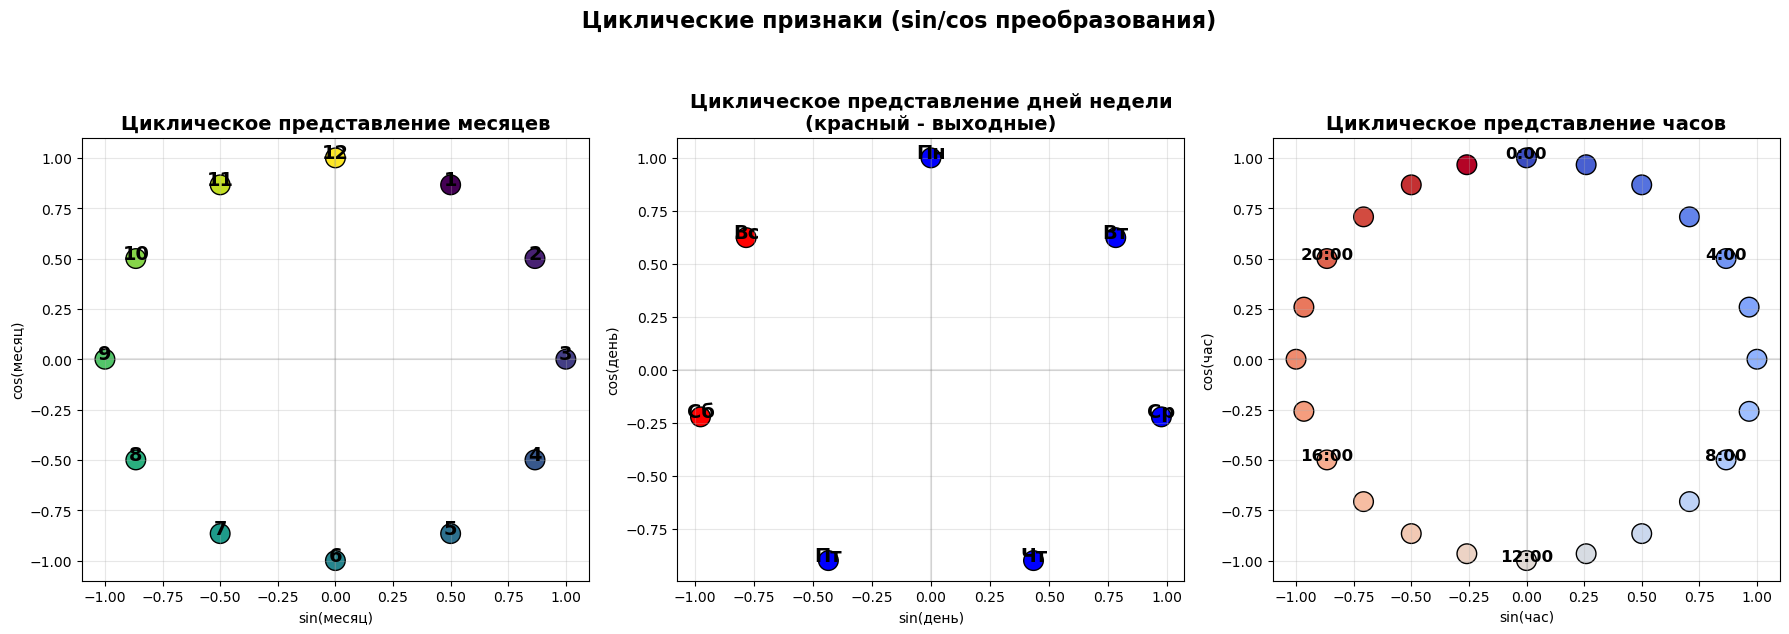


 Первые 10 строк лаговых признаков:
                 Дата  Количество  Количество_лаг_1час  Количество_лаг_3час  Количество_лаг_6час  Количество_лаг_12час  Количество_лаг_24час  Количество_лаг_168час  Количество_среднее_3ч  Количество_среднее_6ч  Количество_среднее_12ч  Количество_среднее_24ч
0 2022-11-11 15:00:00      1808.0                  NaN                  NaN                  NaN                   NaN                   NaN                    NaN                    NaN                    NaN                     NaN                     NaN
1 2022-11-11 18:00:00      1632.0               1808.0                  NaN                  NaN                   NaN                   NaN                    NaN            1808.000000            1808.000000             1808.000000             1808.000000
2 2022-11-11 23:00:00      3440.0               1632.0                  NaN                  NaN                   NaN                   NaN                    NaN            1720.000000   

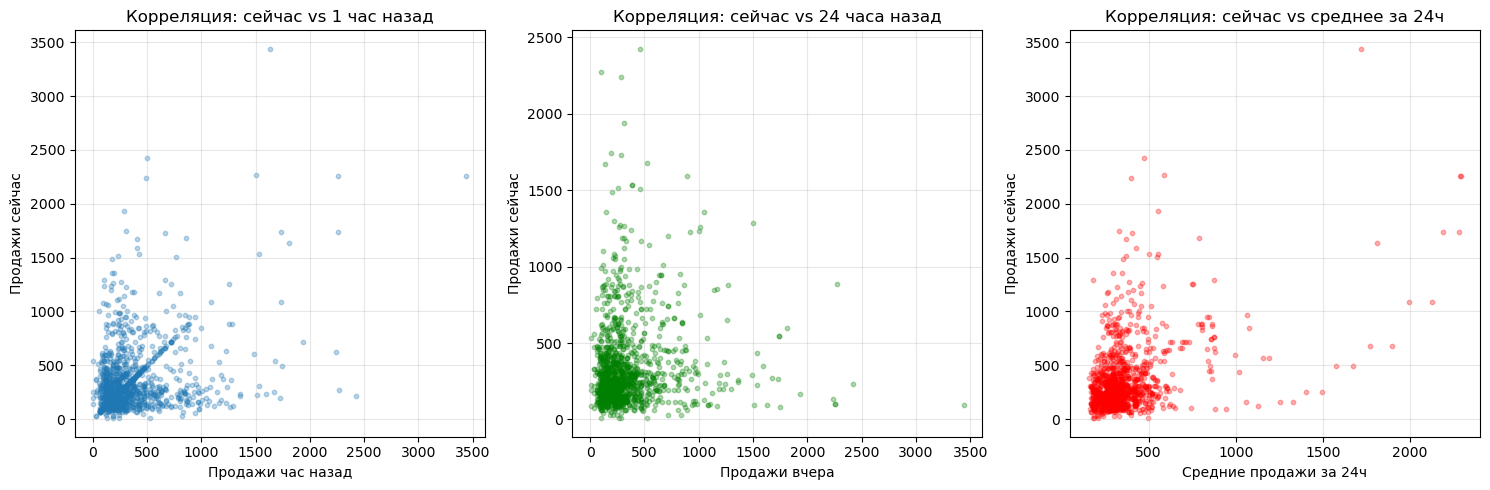


 Пропуски в лаговых признаках (%):
   Количество_лаг_1час: 0.08% пропусков
   Количество_лаг_3час: 0.23% пропусков
   Количество_лаг_6час: 0.46% пропусков
   Количество_лаг_12час: 0.92% пропусков
   Количество_лаг_24час: 1.83% пропусков
   Количество_лаг_168час: 12.84% пропусков

Статистика признаков по организациям:
       org_mean_sales  org_std_sales
count     1308.000000    1308.000000
mean       348.391437     299.008592
std         58.563926      66.983225
min        298.914810     242.419079
25%        298.914810     242.419079
50%        298.914810     242.419079
75%        417.658716     378.233910
max        417.658716     378.233910

Статистика признаков по контрагентам:
       kontr_mean_sales  kontr_std_sales
count       1308.000000      1308.000000
mean         348.391437       281.816984
std           92.716730        99.608619
min           36.000000         5.656854
25%          288.391608       203.755927
50%          350.588235       340.133906
75%          417.6587

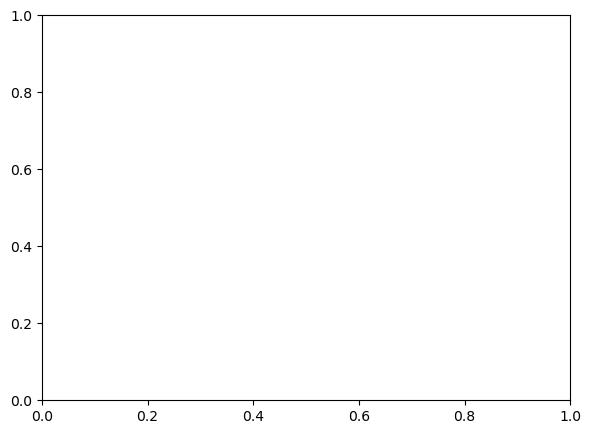

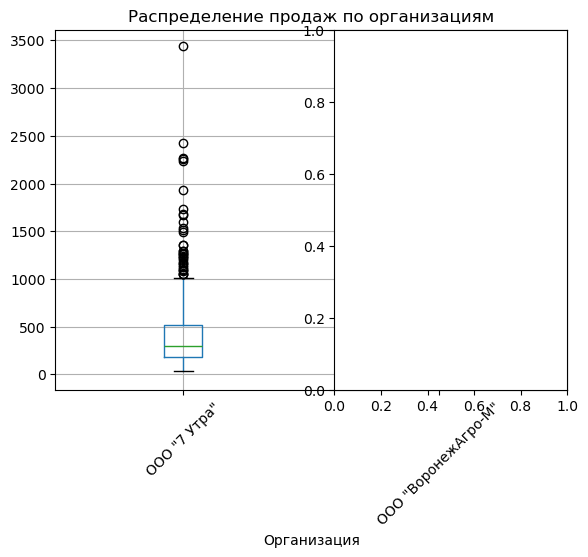

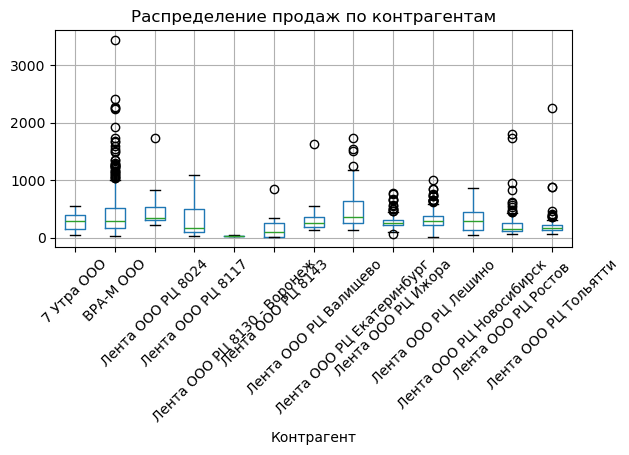

Всего записей (часов): 1308
Всего признаков: 45
Период данных: с 2022-11-11 15:00:00 по 2026-03-06 00:00:00
Всего уникальных организаций: 2
Всего уникальных контрагентов: 13


In [15]:
# Визуализация циклических признаков
plt.figure(figsize=(18, 6))

#  Месяцы на окружности
plt.subplot(1, 3, 1)
months = df_features.groupby('Месяц')[['Месяц_sin', 'Месяц_cos']].mean()
plt.scatter(months['Месяц_sin'], months['Месяц_cos'], c=months.index, cmap='viridis', s=200, edgecolor='black')
for i, (sin, cos) in months.iterrows():
    plt.annotate(f'{int(i)}', (sin, cos), fontsize=14, ha='center', fontweight='bold')
plt.title('Циклическое представление месяцев', fontsize=14, fontweight='bold')
plt.xlabel('sin(месяц)')
plt.ylabel('cos(месяц)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)

#  Дни недели на окружности
plt.subplot(1, 3, 2)
days = df_features.groupby('День_недели')[['День_недели_sin', 'День_недели_cos']].mean()
days_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
colors = ['red' if i in [5,6] else 'blue' for i in days.index]  # выходные - красным
plt.scatter(days['День_недели_sin'], days['День_недели_cos'], c=colors, s=200, edgecolor='black')
for i, (sin, cos) in days.iterrows():
    plt.annotate(days_names[int(i)], (sin, cos), fontsize=14, ha='center', fontweight='bold')
plt.title('Циклическое представление дней недели\n(красный - выходные)', fontsize=14, fontweight='bold')
plt.xlabel('sin(день)')
plt.ylabel('cos(день)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)

#  Часы на окружности
plt.subplot(1, 3, 3)
hours = df_features.groupby('Час')[['Час_sin', 'Час_cos']].mean()
# Цвет от светло-желтого (утро) до темно-синего (ночь)
colors_hours = plt.cm.YlOrRd(hours.index / 24)
plt.scatter(hours['Час_sin'], hours['Час_cos'], c=hours.index, cmap='coolwarm', s=200, edgecolor='black')
for i, (sin, cos) in hours.iterrows():
    if i % 4 == 0:  # показываем каждый 4-й час
        plt.annotate(f'{int(i)}:00', (sin, cos), fontsize=12, ha='center', fontweight='bold')
plt.title('Циклическое представление часов', fontsize=14, fontweight='bold')
plt.xlabel('sin(час)')
plt.ylabel('cos(час)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)

plt.suptitle(' Циклические признаки (sin/cos преобразования)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#  Анализ лаговых признаков
# Выбираем основные лаговые признаки
lag_features = ['Дата', 'Количество', 
                'Количество_лаг_1час', 'Количество_лаг_3час', 'Количество_лаг_6час',
                'Количество_лаг_12час', 'Количество_лаг_24час', 'Количество_лаг_168час',
                'Количество_среднее_3ч', 'Количество_среднее_6ч', 'Количество_среднее_12ч', 
                'Количество_среднее_24ч']

# Показываем первые строки
print("\n Первые 10 строк лаговых признаков:")
print(df_features[lag_features].head(10).to_string())

#Корреляция с лагами
print("\nКорреляция текущих продаж с лаговыми признаками:")
lag_corr = df_features[['Количество', 
                        'Количество_лаг_1час', 'Количество_лаг_3час', 
                        'Количество_лаг_6час', 'Количество_лаг_12час',
                        'Количество_лаг_24час', 'Количество_лаг_168час']].corr()['Количество'].sort_values(ascending=False)
print(lag_corr)

# 6. Визуализация связи с лагами
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df_features['Количество_лаг_1час'], df_features['Количество'], alpha=0.3, s=10)
plt.title('Корреляция: сейчас vs 1 час назад')
plt.xlabel('Продажи час назад')
plt.ylabel('Продажи сейчас')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(df_features['Количество_лаг_24час'], df_features['Количество'], alpha=0.3, s=10, color='green')
plt.title('Корреляция: сейчас vs 24 часа назад')
plt.xlabel('Продажи вчера')
plt.ylabel('Продажи сейчас')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(df_features['Количество_среднее_24ч'], df_features['Количество'], alpha=0.3, s=10, color='red')
plt.title('Корреляция: сейчас vs среднее за 24ч')
plt.xlabel('Средние продажи за 24ч')
plt.ylabel('Продажи сейчас')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Статистика по пропускам в лагах
print("\n Пропуски в лаговых признаках (%):")
lag_missing = df_features[['Количество_лаг_1час', 'Количество_лаг_3час', 
                           'Количество_лаг_6час', 'Количество_лаг_12час',
                           'Количество_лаг_24час', 'Количество_лаг_168час']].isnull().sum()
lag_missing_pct = (lag_missing / len(df_features) * 100).round(2)
for feat, pct in lag_missing_pct.items():
    print(f"   {feat}: {pct}% пропусков")

# 8. Признаки по организациям и контрагентам

org_features = ['org_mean_sales', 'org_std_sales']
kontr_features = ['kontr_mean_sales', 'kontr_std_sales']

print("\nСтатистика признаков по организациям:")
print(df_features[org_features].describe())

print("\nСтатистика признаков по контрагентам:")
print(df_features[kontr_features].describe())

#  Сравнение распределений
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
df_features.boxplot(column='Количество', by='Организация')
plt.title('Распределение продаж по организациям')
plt.suptitle('')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df_features.boxplot(column='Количество', by='Контрагент')
plt.title('Распределение продаж по контрагентам')
plt.suptitle('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#  Итоговая статистика по всем признакам
print(f"Всего записей (часов): {len(df_features)}")
print(f"Всего признаков: {len(df_features.columns)}")
print(f"Период данных: с {df_features['Дата'].min()} по {df_features['Дата'].max()}")
print(f"Всего уникальных организаций: {df_features['Организация'].nunique()}")
print(f"Всего уникальных контрагентов: {df_features['Контрагент'].nunique()}")

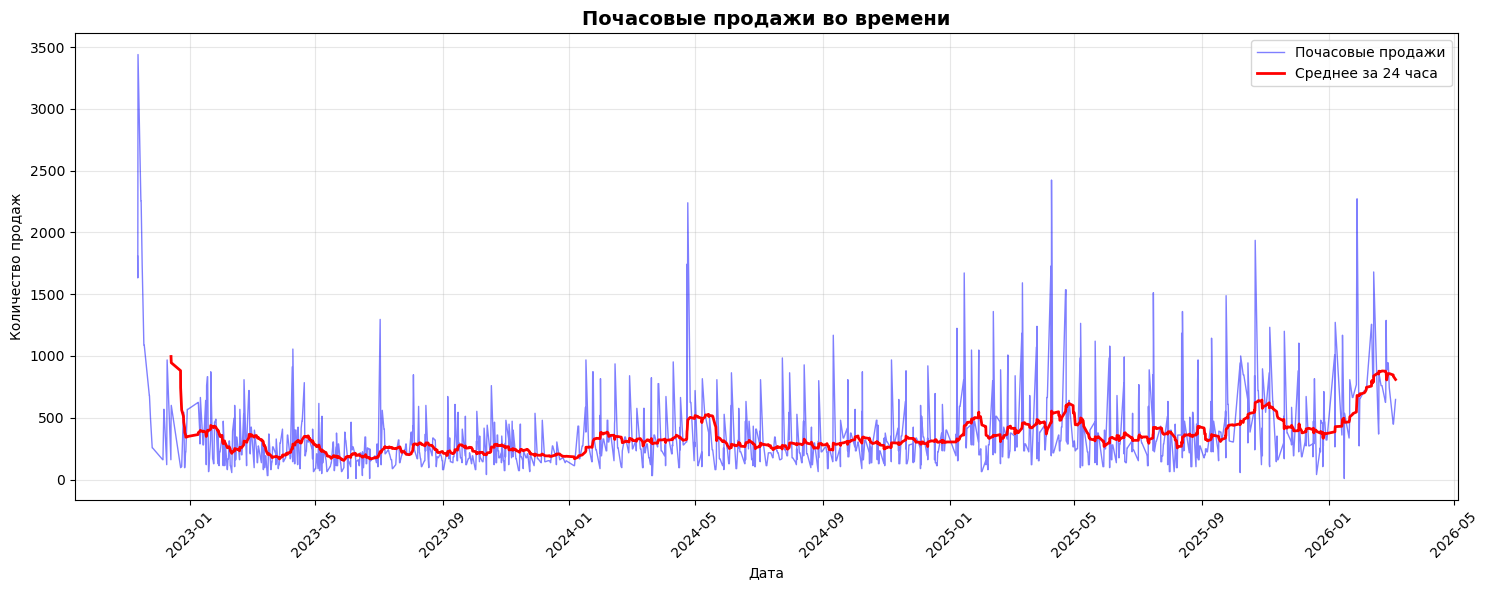


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Суммарные продажи по часам_20260310.pdf
    Всего сохранено: 1 объектов


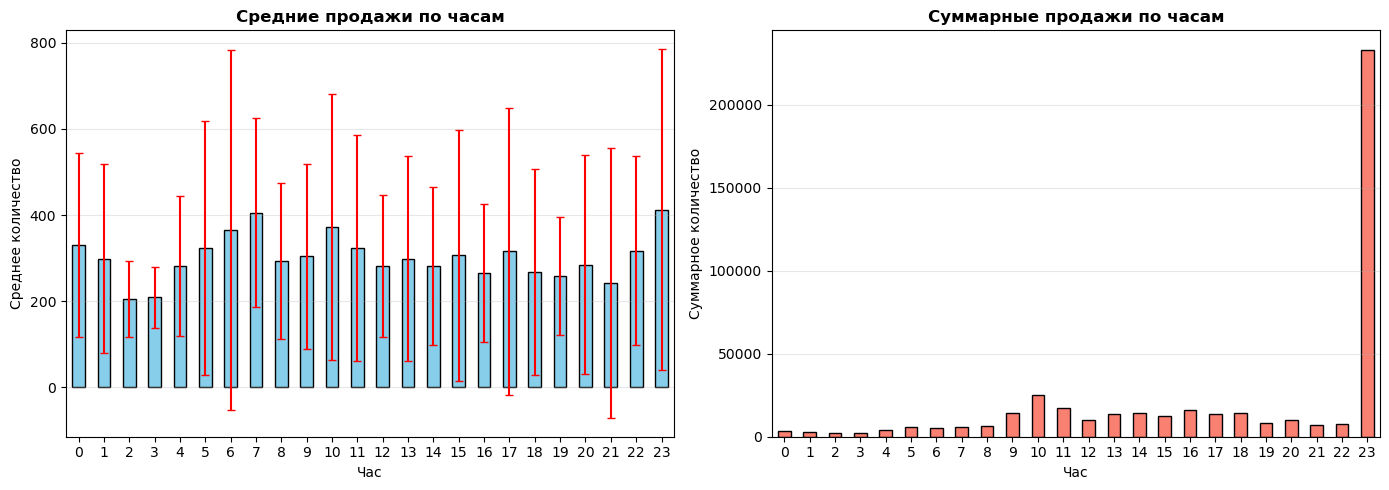

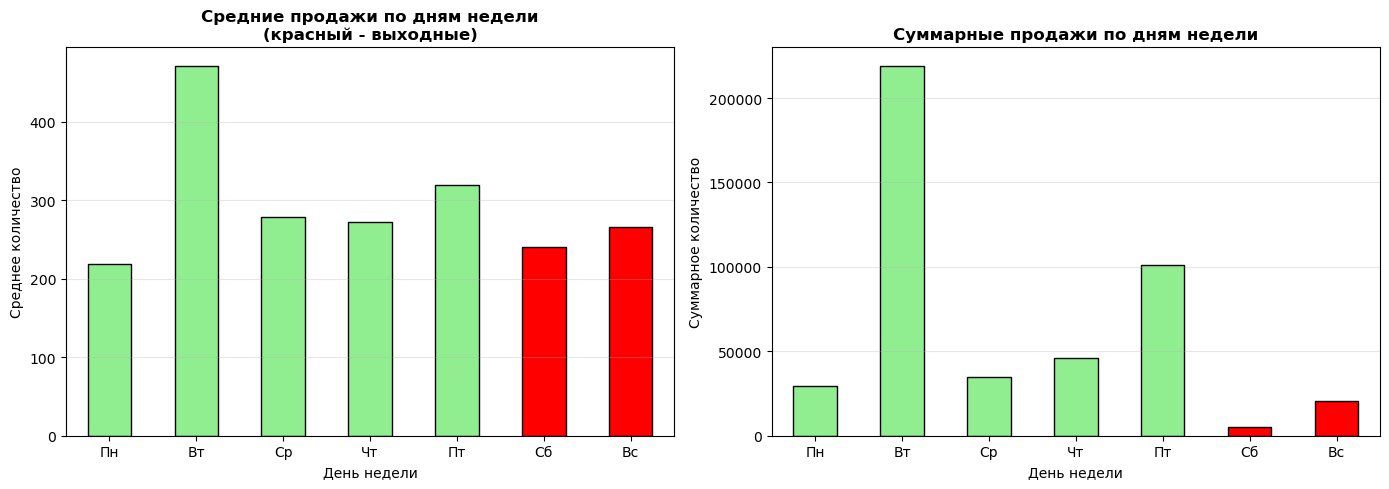


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Суммарные продажи по месяцам_20260310.pdf
    Всего сохранено: 1 объектов


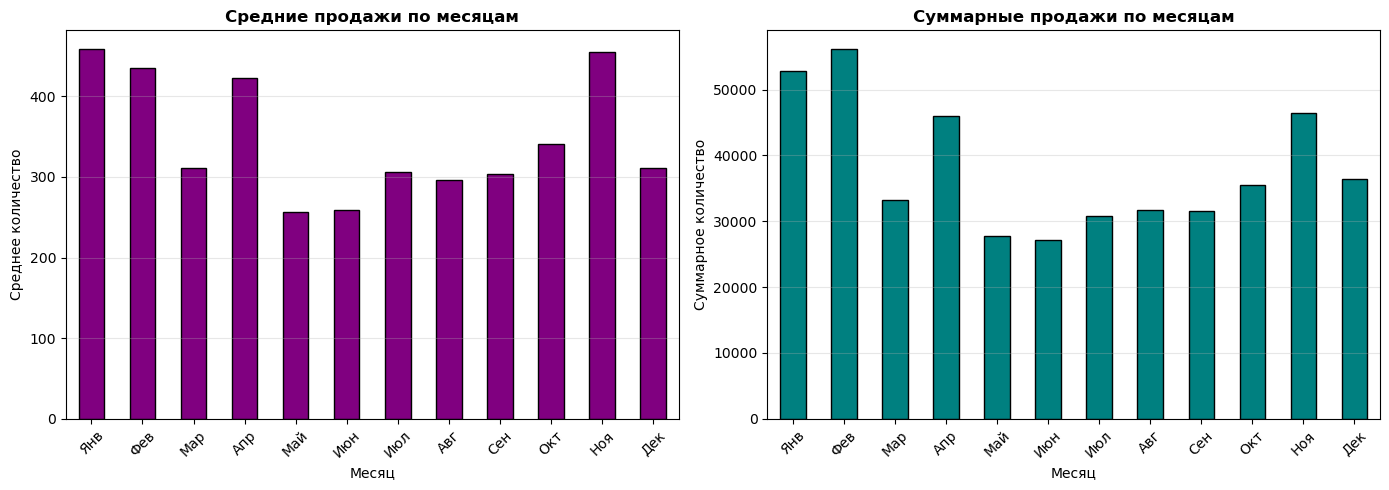


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Корреляция между признаками_20260310.pdf
    Всего сохранено: 1 объектов


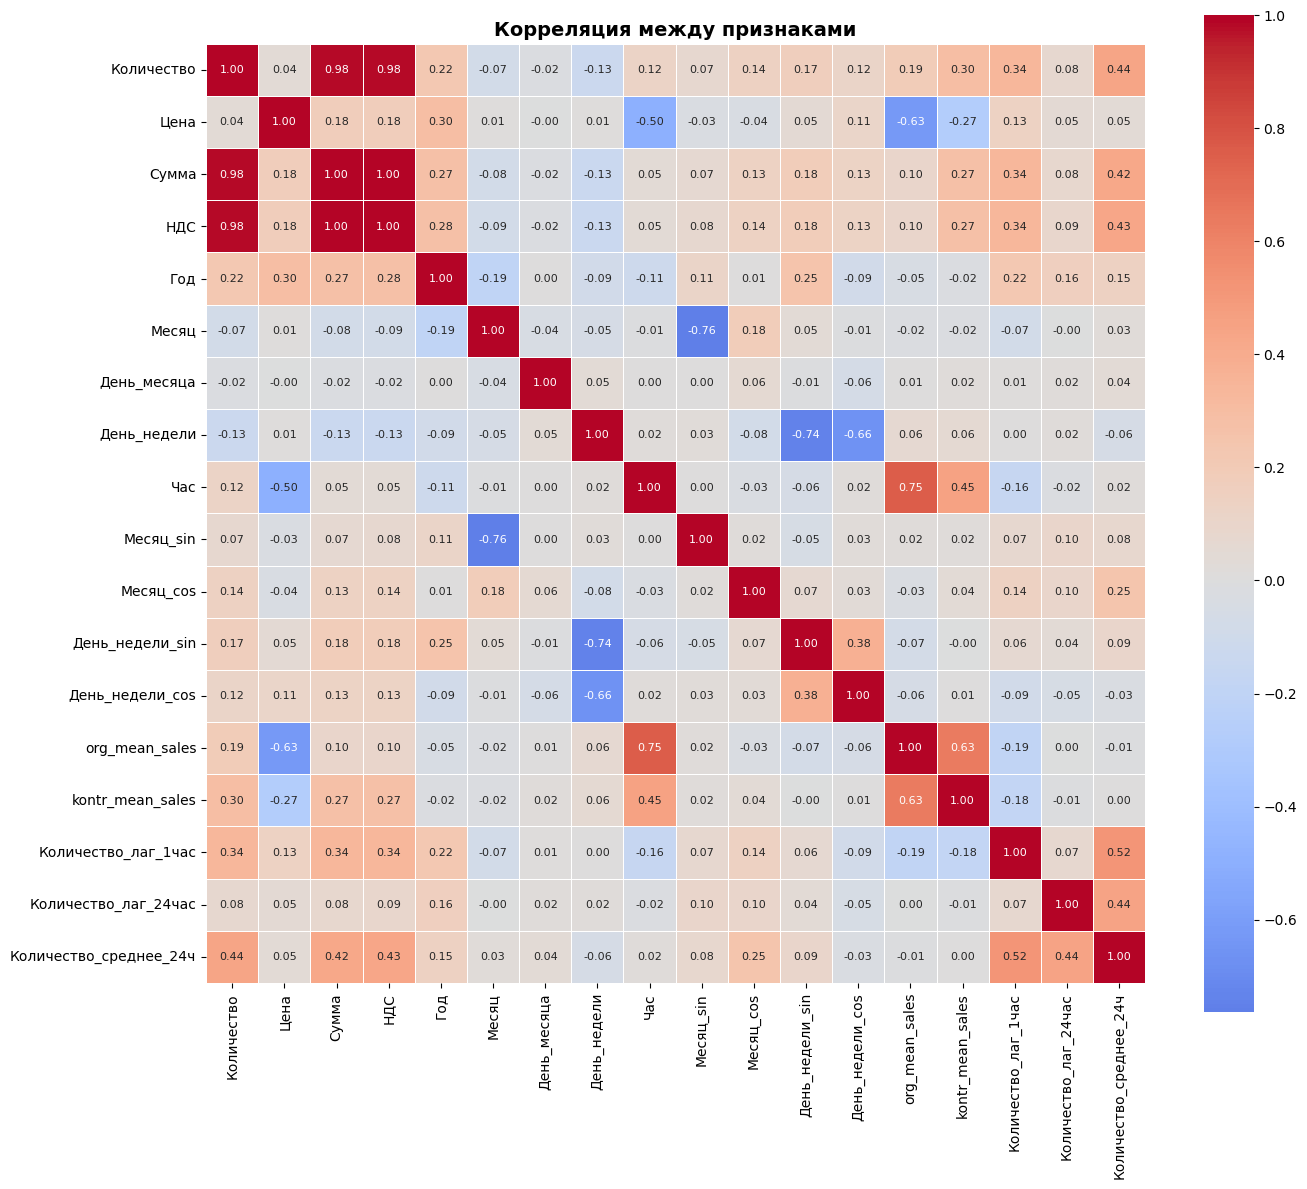


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Средние продажи по организациям_20260310.pdf
    Всего сохранено: 1 объектов


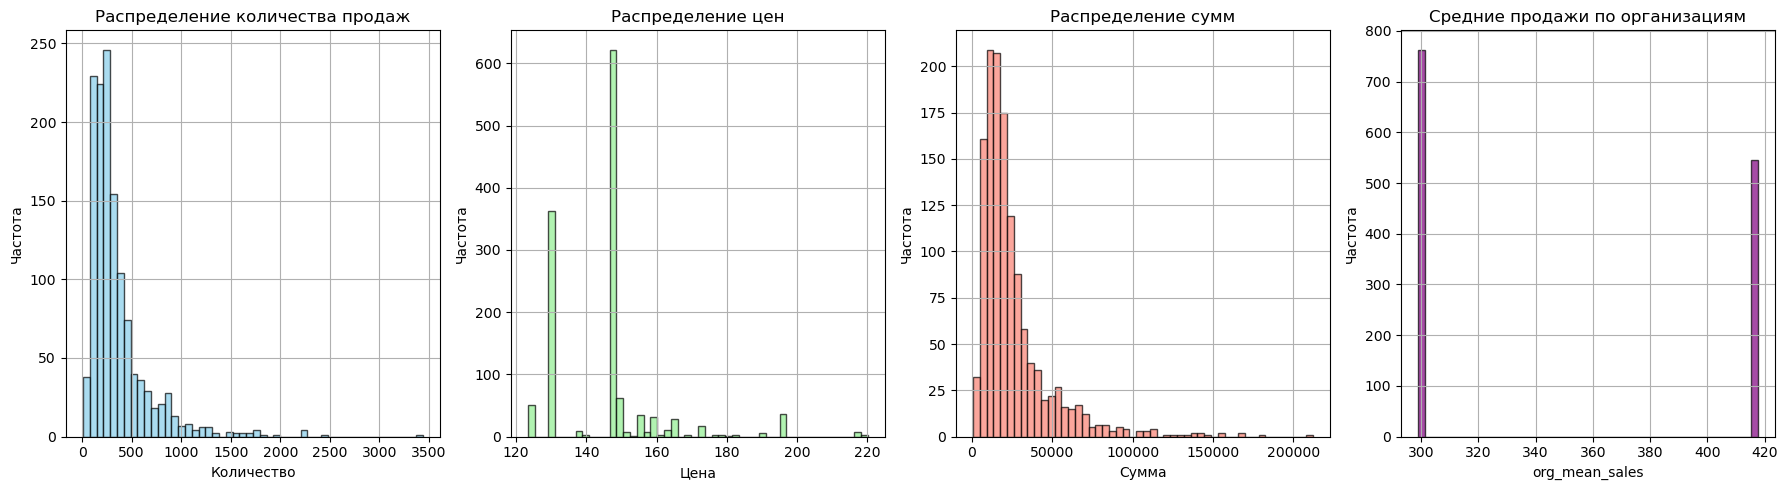


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Распределение продаж по часам (box plot, без 1_ выбросов)_20260310.pdf
    Всего сохранено: 1 объектов


<Figure size 1500x600 with 0 Axes>

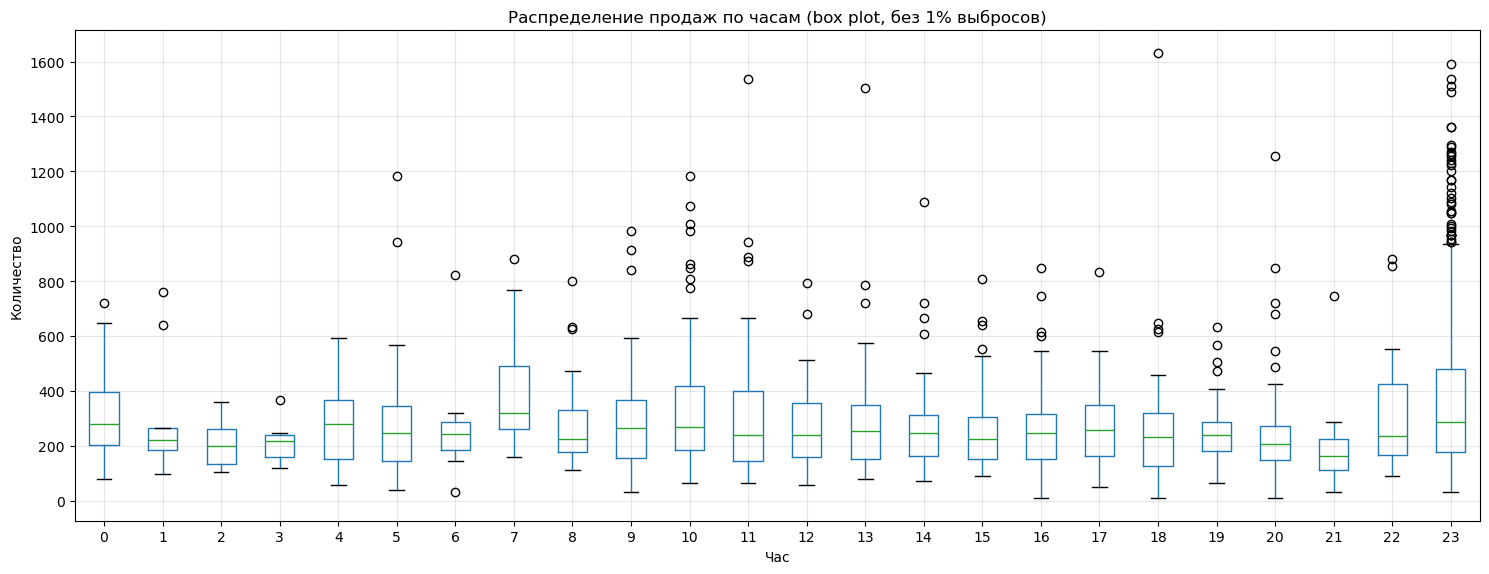

<Figure size 1400x1200 with 0 Axes>

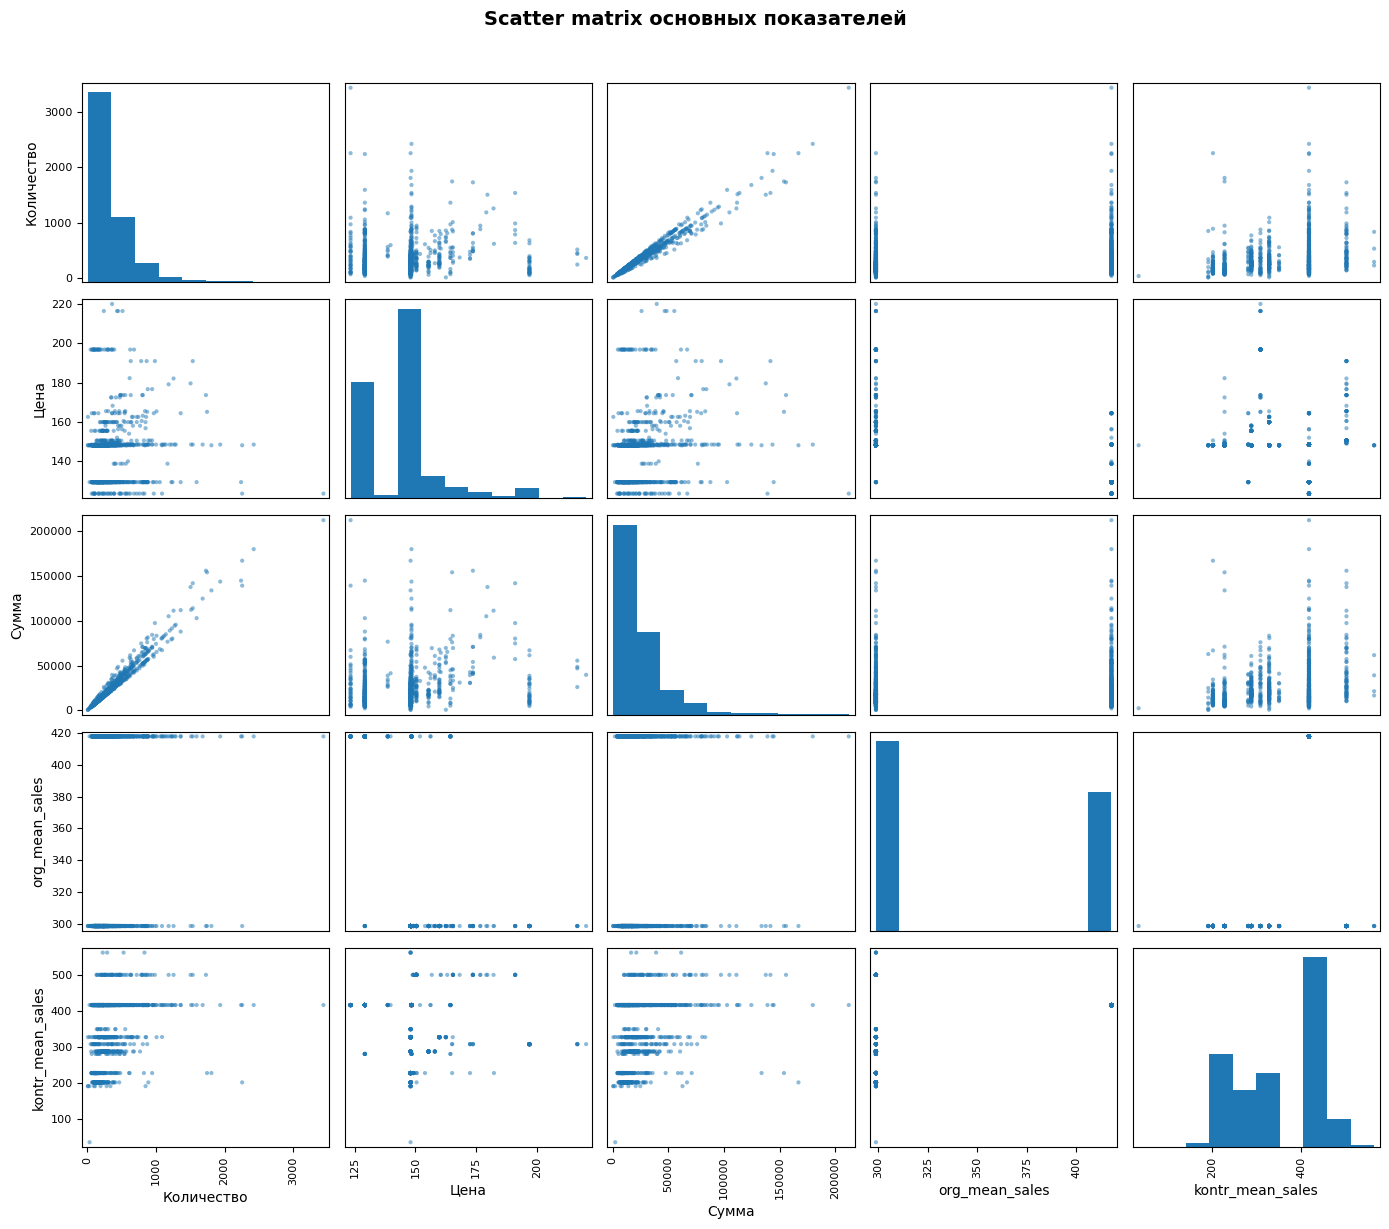


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Средние продажи по организациям (топ-10)_20260310.pdf
    Всего сохранено: 1 объектов


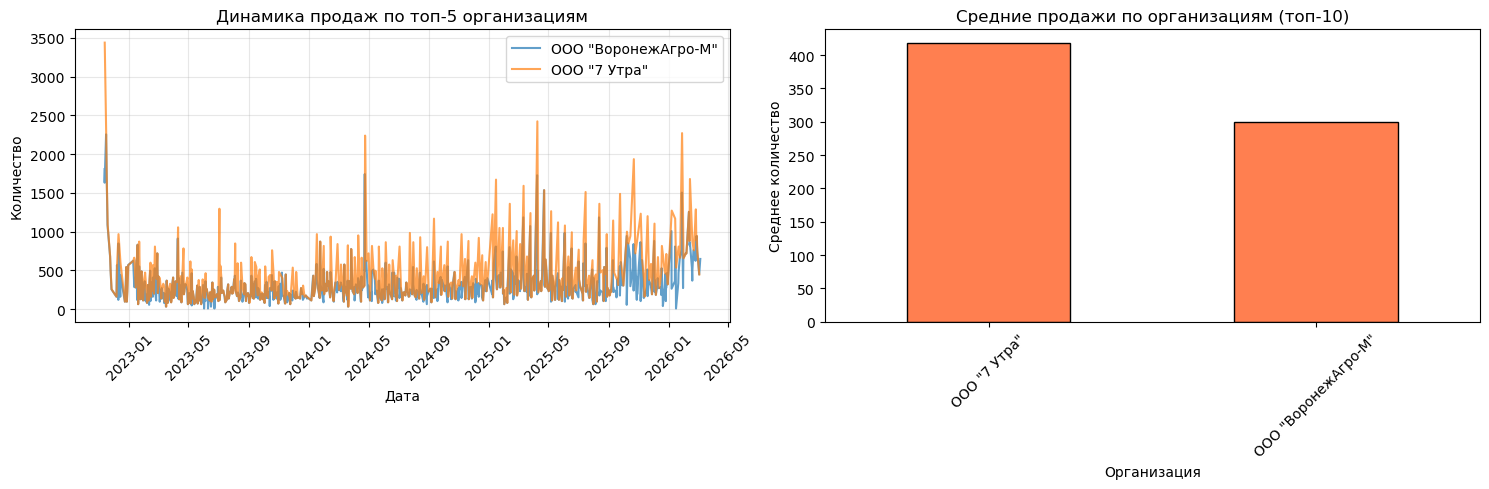


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Тепловая карта_ продажи по дням недели × месяцам_20260310.pdf
    Всего сохранено: 1 объектов


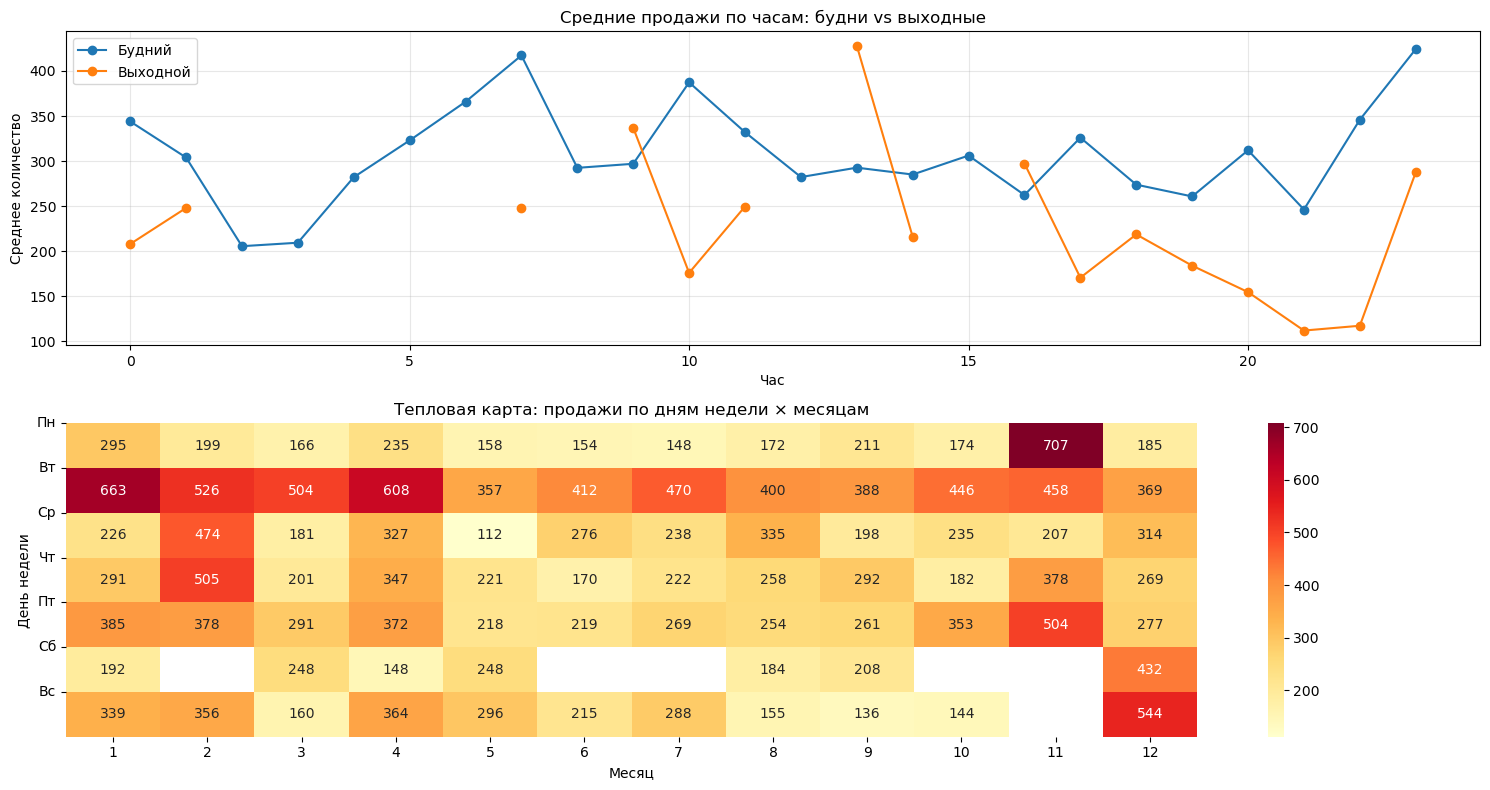


Визуализация завершена!
 Train сохранен: datasets/данные_с_признаками/train_test_split/train_20260310_134233.parquet
 Test сохранен: datasets/данные_с_признаками/train_test_split/test_20260310_134233.parquet
 Метаданные сохранены: datasets/данные_с_признаками/train_test_split/split_info_20260310_134233.json


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



#  Временной ряд - почасовые продажи
plt.figure(figsize=(15, 6))

# Сумма продаж по часам
plt.plot(df_features['Дата'], df_features['Количество'], 
         linewidth=1, color='blue', alpha=0.5, label='Почасовые продажи')

# Добавляем скользящее среднее (24 часа)
df_features['Количество_среднее_24ч_виз'] = df_features['Количество'].rolling(window=24).mean()
plt.plot(df_features['Дата'], df_features['Количество_среднее_24ч_виз'], 
         linewidth=2, color='red', label='Среднее за 24 часа')

plt.title('Почасовые продажи во времени', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Продажи по часам (среднее и сумма)
plt.figure(figsize=(14, 5))

# Группируем по часу
hourly_stats = df_features.groupby('Час')['Количество'].agg(['mean', 'sum', 'count', 'std']).round(2)

# Средние продажи по часам
plt.subplot(1, 2, 1)
hourly_stats['mean'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Средние продажи по часам', fontsize=12, fontweight='bold')
plt.xlabel('Час')
plt.ylabel('Среднее количество')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем стандартное отклонение
plt.errorbar(x=range(24), y=hourly_stats['mean'], 
             yerr=hourly_stats['std'], fmt='none', color='red', capsize=3)

# Суммарные продажи по часам
plt.subplot(1, 2, 2)
hourly_stats['sum'].plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Суммарные продажи по часам', fontsize=12, fontweight='bold')
plt.xlabel('Час')
plt.ylabel('Суммарное количество')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Суммарные продажи по часам_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

#  Продажи по дням недели
plt.figure(figsize=(14, 5))

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_stats = df_features.groupby('День_недели')['Количество'].agg(['mean', 'sum', 'std'])

# Средние продажи по дням недели
plt.subplot(1, 2, 1)
colors = ['red' if i in [5,6] else 'lightgreen' for i in range(7)]
weekday_stats['mean'].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Средние продажи по дням недели\n(красный - выходные)', fontsize=12, fontweight='bold')
plt.xlabel('День недели')
plt.ylabel('Среднее количество')
plt.xticks(ticks=range(7), labels=days, rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Суммарные продажи по дням недели
plt.subplot(1, 2, 2)
weekday_stats['sum'].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Суммарные продажи по дням недели', fontsize=12, fontweight='bold')
plt.xlabel('День недели')
plt.ylabel('Суммарное количество')
plt.xticks(ticks=range(7), labels=days, rotation=0)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  Анализ по месяцам
plt.figure(figsize=(14, 5))

monthly_stats = df_features.groupby('Месяц')['Количество'].agg(['mean', 'sum', 'std'])
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.subplot(1, 2, 1)
monthly_stats['mean'].plot(kind='bar', color='purple', edgecolor='black')
plt.title('Средние продажи по месяцам', fontsize=12, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Среднее количество')
plt.xticks(ticks=range(12), labels=months, rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
monthly_stats['sum'].plot(kind='bar', color='teal', edgecolor='black')
plt.title('Суммарные продажи по месяцам', fontsize=12, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Суммарное количество')
plt.xticks(ticks=range(12), labels=months, rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Суммарные продажи по месяцам_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

#  Корреляционная матрица (расширенная)
plt.figure(figsize=(14, 12))

# Выбираем основные числовые признаки
numeric_cols = ['Количество', 'Цена', 'Сумма', 'НДС',
                'Год', 'Месяц', 'День_месяца', 'День_недели', 'Час',
                'Месяц_sin', 'Месяц_cos', 'День_недели_sin', 'День_недели_cos',
                'org_mean_sales', 'kontr_mean_sales',
                'Количество_лаг_1час', 'Количество_лаг_24час', 'Количество_среднее_24ч']

# Берем только существующие колонки
existing_cols = [col for col in numeric_cols if col in df_features.columns]
correlation_matrix = df_features[existing_cols].corr()

# Тепловая карта
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Корреляция между признаками', fontsize=14, fontweight='bold')
plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Корреляция между признаками_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

#  Распределение ключевых показателей
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
df_features['Количество'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение количества продаж', fontsize=12)
plt.xlabel('Количество')
plt.ylabel('Частота')

plt.subplot(1, 4, 2)
df_features['Цена'].hist(bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Распределение цен', fontsize=12)
plt.xlabel('Цена')
plt.ylabel('Частота')

plt.subplot(1, 4, 3)
df_features['Сумма'].hist(bins=50, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Распределение сумм', fontsize=12)
plt.xlabel('Сумма')
plt.ylabel('Частота')

plt.subplot(1, 4, 4)
df_features['org_mean_sales'].hist(bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.title('Средние продажи по организациям', fontsize=12)
plt.xlabel('org_mean_sales')
plt.ylabel('Частота')

plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Средние продажи по организациям_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()



#  Box plot по часам (для выявления выбросов)
plt.figure(figsize=(15, 6))

# Ограничим данные для лучшей визуализации (удалим экстремальные выбросы)
q99 = df_features['Количество'].quantile(0.99)
df_clean = df_features[df_features['Количество'] <= q99]

df_clean.boxplot(column='Количество', by='Час', figsize=(15, 6))
plt.title('Распределение продаж по часам (box plot, без 1% выбросов)')
plt.suptitle('')
plt.xlabel('Час')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Распределение продаж по часам (box plot, без 1% выбросов)_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

#  Scatter plot матрица основных показателей
plt.figure(figsize=(14, 12))
selected_cols = ['Количество', 'Цена', 'Сумма', 'org_mean_sales', 'kontr_mean_sales']
existing_selected = [col for col in selected_cols if col in df_features.columns]

if len(existing_selected) > 1:
    pd.plotting.scatter_matrix(df_features[existing_selected].sample(min(1000, len(df_features))), 
                               alpha=0.5, figsize=(14, 12), diagonal='hist')
    plt.suptitle('Scatter matrix основных показателей', y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

#  Анализ по организациям (топ-5)
plt.figure(figsize=(15, 5))

top_orgs = df_features.groupby('Организация')['Количество'].sum().nlargest(5).index
df_top_orgs = df_features[df_features['Организация'].isin(top_orgs)]

plt.subplot(1, 2, 1)
for org in top_orgs:
    org_data = df_top_orgs[df_top_orgs['Организация'] == org]
    plt.plot(org_data['Дата'], org_data['Количество'], label=str(org)[:20], alpha=0.7)
plt.title('Динамика продаж по топ-5 организациям')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
org_means = df_features.groupby('Организация')['Количество'].mean().sort_values(ascending=False).head(10)
org_means.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Средние продажи по организациям (топ-10)')
plt.xlabel('Организация')
plt.ylabel('Среднее количество')
plt.xticks(rotation=45)

plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Средние продажи по организациям (топ-10)_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

#  Сезонная декомпозиция (простая)
plt.figure(figsize=(15, 8))

# Средние продажи по часам для будних и выходных
df_features['Тип_дня'] = df_features['День_недели'].apply(lambda x: 'Выходной' if x in [5,6] else 'Будний')

hourly_by_daytype = df_features.groupby(['Тип_дня', 'Час'])['Количество'].mean().unstack(0)

plt.subplot(2, 1, 1)
hourly_by_daytype.plot(marker='o', ax=plt.gca())
plt.title('Средние продажи по часам: будни vs выходные')
plt.xlabel('Час')
plt.ylabel('Среднее количество')
plt.grid(True, alpha=0.3)
plt.legend()


# Средние продажи по дням недели для разных месяцев
plt.subplot(2, 1, 2)
pivot_table = df_features.pivot_table(values='Количество', index='День_недели', columns='Месяц', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Тепловая карта: продажи по дням недели × месяцам')
plt.xlabel('Месяц')
plt.ylabel('День недели')
plt.yticks(ticks=range(7), labels=days, rotation=0)

plt.tight_layout()

save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Тепловая карта: продажи по дням недели × месяцам_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()



print("\nВизуализация завершена!")
# Сохраняем датасет с признаками в Minio
if 'weekly_forecast' in locals() or 'weekly_forecast' in globals():
    save_datasets_to_minio(  # <-- ИСПРАВЛЕНО: save_datasets_to_minio
        train_df=weekly_forecast,  # обратите внимание: train_df, а не df
        test_df=None,  # нужно передать test_df, даже если None
        product_name="прогноз_еженедельный",  #  product_name вместо filename
        bucket_name="ml-datasets",
        split_info={
            'description': 'Еженедельный прогноз',
            'rows': len(weekly_forecast)
        }
    )

if 'df_features' in locals() or 'df_features' in globals():
    save_datasets_to_minio(
        train_df=df_features,
        test_df=df_features,  # <-- ВАЖНО: передаем тот же датасет вместо None
        product_name="данные_с_признаками",
        bucket_name="ml-datasets",
        split_info={
            'description': 'Полный датасет с признаками',
            'feature_count': len(df_features.columns),
            'row_count': len(df_features)
        }
    )

 Ежедневные продажи: 566 дней
   С 2022-11-11 00:00:00 по 2026-03-06 00:00:00


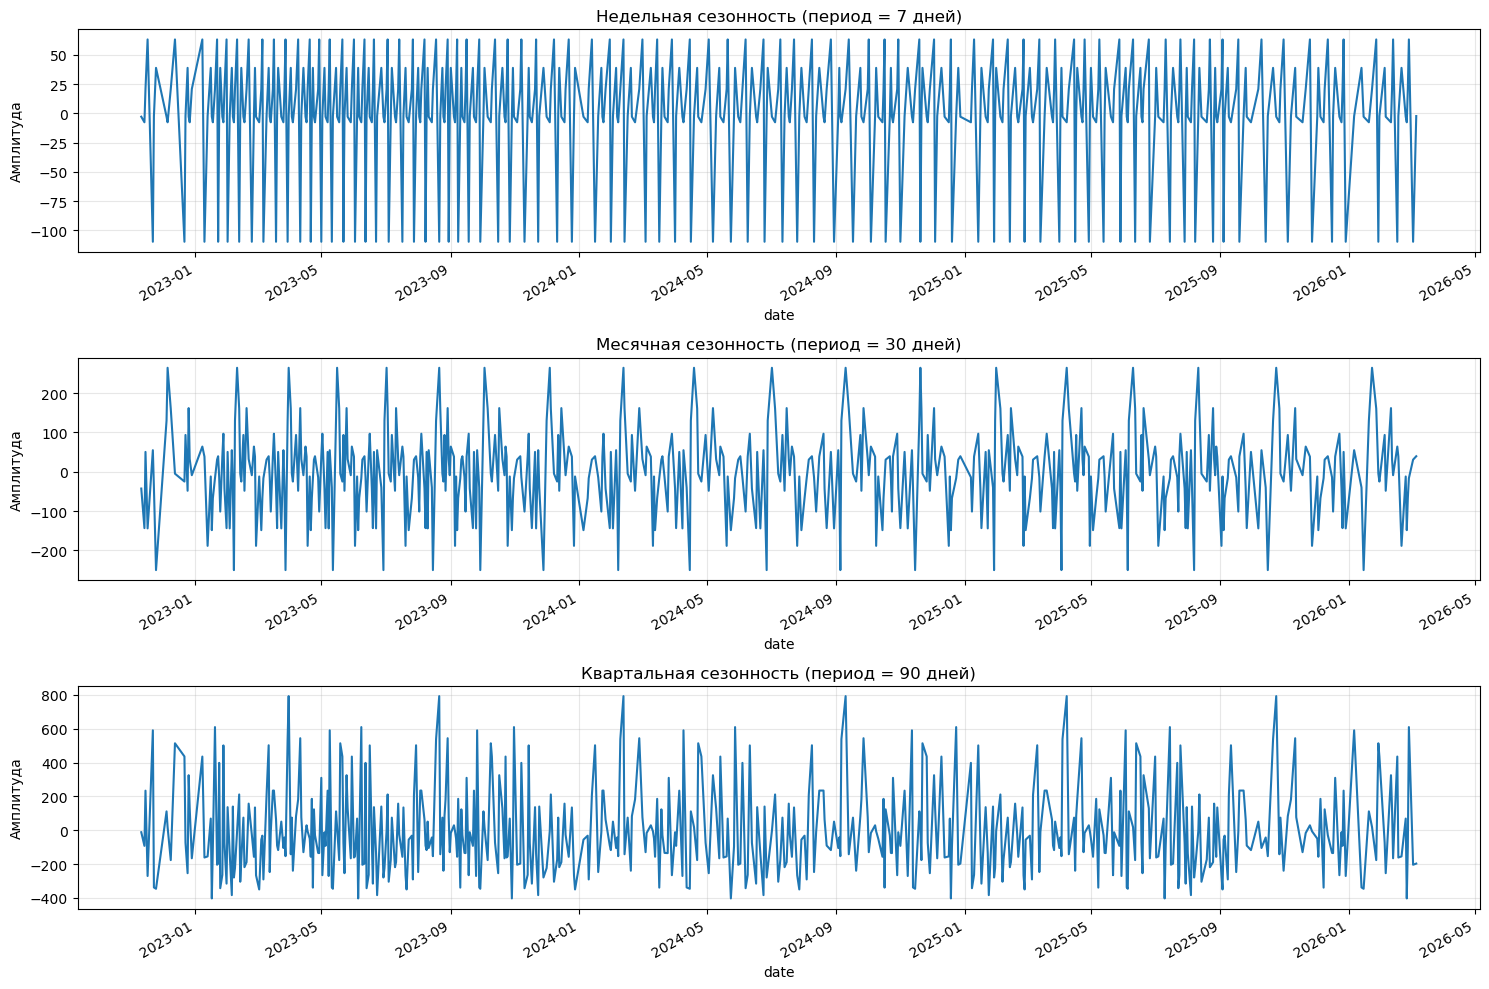


 Сохраняем в Minio: sales-analytics/Пр.из творога 365 дней 24проц 500г пакет 8шт
 PDF: http://localhost:9003/sales-analytics/2026-03-10/Пр.из творога 365 дней 24проц 500г пакет 8шт/Декомпозиция временного ряда продаж_20260310.pdf
    Всего сохранено: 1 объектов


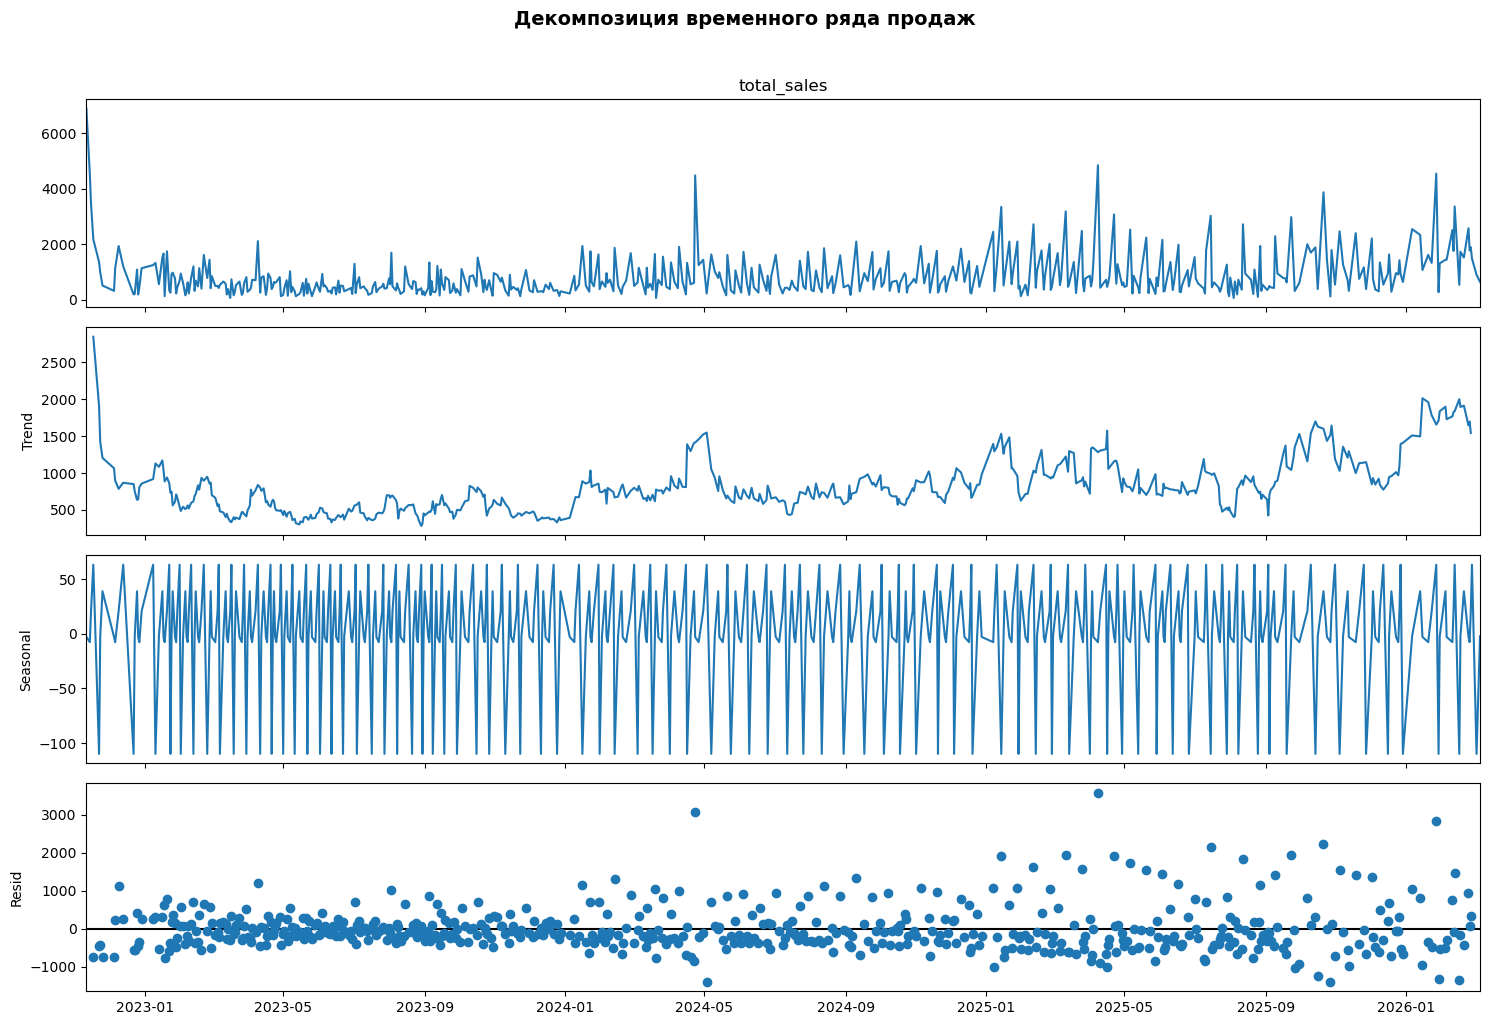


Анализ компонент:
Тренд: 285 - 2843
Сезонность: от -110 до 63
Остатки (шум): стандартное отклонение = 582.57


In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Сначала нужно агрегировать ваши почасовые данные по дням
daily_sales = df_features.groupby(df_features['Дата'].dt.date)['Количество'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.set_index('date')['total_sales']

print(f" Ежедневные продажи: {len(daily_sales)} дней")
print(f"   С {daily_sales.index.min()} по {daily_sales.index.max()}")

# Пробуем разные периоды сезонности
periods = {
    7: 'Недельная',
    30: 'Месячная',
    90: 'Квартальная'
}

plt.figure(figsize=(15, 10))

for i, (period, period_name) in enumerate(periods.items(), 1):
    try:
        # Декомпозиция
        decomposition = seasonal_decompose(daily_sales, model='additive', period=period)
        
        # Визуализация
        plt.subplot(3, 1, i)
        decomposition.seasonal.plot()
        plt.title(f'{period_name} сезонность (период = {period} дней)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        
    except Exception as e:
        print(f"Не удалось выполнить декомпозицию с периодом {period}: {e}")

plt.tight_layout()

plt.show()

# Полная декомпозиция для лучшего периода (например, 7 дней)


decomposition = seasonal_decompose(daily_sales, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Декомпозиция временного ряда продаж', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_to_minio(
    bucket_name="sales-analytics",
    block_name="Пр.из творога 365 дней 24проц 500г пакет 8шт",
    plot_name=f"Декомпозиция временного ряда продаж_{datetime.now().strftime('%Y%m%d')}",  
    data=None,  
    fig=plt.gcf(),
    formats=['pdf']
)
plt.show()

# Анализ компонент
print("\nАнализ компонент:")
print(f"Тренд: {decomposition.trend.min():.0f} - {decomposition.trend.max():.0f}")
print(f"Сезонность: от {decomposition.seasonal.min():.0f} до {decomposition.seasonal.max():.0f}")
print(f"Остатки (шум): стандартное отклонение = {decomposition.resid.std():.2f}")
if 'weekly_forecast' in locals() or 'weekly_forecast' in globals():
    save_datasets_to_minio(
        train_df=weekly_forecast,
        test_df=weekly_forecast,
        product_name="еженедельный_прогноз",
        bucket_name="ml-datasets",
        split_info={
            'description': 'Еженедельный прогноз продаж',
            'type': 'forecast',
            'rows': len(weekly_forecast),
            'created_at': datetime.now().isoformat()
        }
    )
    print(" Прогноз сохранен в Minio")

In [25]:
# 1. Сначала удалим дубликаты колонок
print(f"Было колонок: {len(df_features.columns)}")
df_features = df_features.loc[:, ~df_features.columns.duplicated()]
print(f"После удаления дубликатов: {len(df_features.columns)}")

# 2. Добавим недостающие признаки по организациям и контрагентам
print("\n Добавляем недостающие признаки...")

# Признаки по организациям
org_stats = df_features.groupby('Организация')['Количество'].agg(['mean', 'std']).fillna(0)
org_stats_dict = org_stats.to_dict('index')

df_features['org_mean_sales'] = df_features['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
df_features['org_std_sales'] = df_features['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))

# Признаки по контрагентам
kontr_stats = df_features.groupby('Контрагент')['Количество'].agg(['mean', 'std']).fillna(0)
kontr_stats_dict = kontr_stats.to_dict('index')

df_features['kontr_mean_sales'] = df_features['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
df_features['kontr_std_sales'] = df_features['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))

# 3. Добавляем признак "тип продажи" (если еще нет)
if 'тип_опт' not in df_features.columns:
    print(" Добавляем типы продаж...")
    df_features['тип_продажи'] = df_features['Количество'].apply(
        lambda x: 'опт' if x > 500 else ('розница' if x > 50 else 'мелкая_розница')
    )
    
    df_features['тип_опт'] = (df_features['тип_продажи'] == 'опт').astype(int)
    df_features['тип_розница'] = (df_features['тип_продажи'] == 'розница').astype(int)
    df_features['тип_мелкая_розница'] = (df_features['тип_продажи'] == 'мелкая_розница').astype(int)
    
    df_features = df_features.drop('тип_продажи', axis=1)

# 4. Проверяем все важные признаки
important_features = [
    'org_mean_sales', 'org_std_sales',
    'kontr_mean_sales', 'kontr_std_sales',
    'Количество_лаг_1час', 'Количество_лаг_24час', 'Количество_среднее_24ч',
    'Месяц_sin', 'Месяц_cos', 'Час_sin', 'Час_cos',
    'тип_опт', 'тип_розница', 'тип_мелкая_розница'
]

print("\n Проверка важных признаков:")
for feat in important_features:
    if feat in df_features.columns:
        print(f"{feat}")
    else:
        print(f" {feat} (отсутствует!)")

# 5. Статистика по типам продаж (исправленная!)
print("\nСтатистика по типам продаж:")
type_cols = ['тип_опт', 'тип_розница', 'тип_мелкая_розница']
for col in type_cols:
    if col in df_features.columns:
        # ИСПРАВЛЕНО: просто берем сумму
        count = df_features[col].sum()
        # Если это Series (редко), берем значение
        if hasattr(count, 'iloc'):
            count = count.iloc[0]
        # Если это numpy int64, преобразуем
        if hasattr(count, 'item'):
            count = count.item()
        print(f"   {col}: {int(count)} записей ({count/len(df_features)*100:.1f}%)")

# 6. Итог
print(f"\nГОТОВО! Всего признаков: {len(df_features.columns)}")
print(f"Размер данных: {df_features.shape}")

Было колонок: 50
После удаления дубликатов: 50

 Добавляем недостающие признаки...

 Проверка важных признаков:
org_mean_sales
org_std_sales
kontr_mean_sales
kontr_std_sales
Количество_лаг_1час
Количество_лаг_24час
Количество_среднее_24ч
Месяц_sin
Месяц_cos
Час_sin
Час_cos
тип_опт
тип_розница
тип_мелкая_розница

Статистика по типам продаж:
   тип_опт: 233 записей (17.8%)
   тип_розница: 1063 записей (81.3%)
   тип_мелкая_розница: 12 записей (0.9%)

ГОТОВО! Всего признаков: 50
Размер данных: (1308, 50)


In [59]:
 #Сохраняем даты для разделения
dates_for_split = df_features['Дата'].copy()

# Удаляем нечисловые колонки (кроме даты)
non_numeric_cols = ['Час_начало', 'Тип_дня', 'Организация', 'Контрагент']
existing_non_numeric = [col for col in non_numeric_cols if col in df_features.columns]
df_features_clean = df_features.drop(columns=existing_non_numeric)

# Разделяем по дате
train_mask = dates_for_split.dt.date < cutoff_date
test_mask = dates_for_split.dt.date >= cutoff_date

# ВАЖНО: удаляем дату из признаков!
df_features_clean = df_features_clean.drop('Дата', axis=1)

# Создаем признаки
target = 'Количество'
feature_columns = [col for col in df_features_clean.columns if col != target]

# Разделяем данные
train_data = df_features_clean[train_mask].copy()
test_data = df_features_clean[test_mask].copy()

X_train = train_data[feature_columns]
y_train = train_data[target]
X_test = test_data[feature_columns]
y_test = test_data[target]

print(f" X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f" X_test: {X_test.shape}, y_test: {y_test.shape}")

 X_train: (1283, 44), y_train: (1283,)
 X_test: (25, 44), y_test: (25,)


In [61]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Оптимизированные параметры
model_tuned = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

print(" Обучаем улучшенную модель...")
model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

y_pred_tuned = model_tuned.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

print(f"\n Результаты улучшенной модели:")
print(f"   MAE: {mae_tuned:.2f}")
print(f"   MAPE: {mape_tuned:.1f}%")

 Обучаем улучшенную модель...
[0]	validation_0-rmse:290.24718	validation_1-rmse:539.36152
[100]	validation_0-rmse:16.23315	validation_1-rmse:52.50912
[120]	validation_0-rmse:14.11703	validation_1-rmse:52.56131

 Результаты улучшенной модели:
   MAE: 35.29
   MAPE: 4.2%


In [62]:
print("\n ОБУЧЕНИЕ РАЗДЕЛЬНЫХ МОДЕЛЕЙ")
print("="*60)

numeric_cols = df_features.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['Количество', 'НДС', 'Цена', 'Сумма']  # что исключаем
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Используем {len(feature_cols)} числовых признаков")

# 2. Модель для опта
opt_mask = df_features['тип_опт'] == 1
df_opt = df_features[opt_mask].copy()

if len(df_opt) > 50:
    print(f"\nОбучаем модель для ОПТА ({len(df_opt)} записей)")
    
    X_opt = df_opt[feature_cols]
    y_opt = df_opt['Количество']
    
    train_size_opt = int(len(X_opt) * 0.8)
    X_opt_train, X_opt_test = X_opt[:train_size_opt], X_opt[train_size_opt:]
    y_opt_train, y_opt_test = y_opt[:train_size_opt], y_opt[train_size_opt:]
    
    model_opt = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42)
    model_opt.fit(X_opt_train, y_opt_train)
    
    y_opt_pred = model_opt.predict(X_opt_test)
    mape_opt = mean_absolute_percentage_error(y_opt_test, y_opt_pred) * 100
    print(f"   MAPE для опта: {mape_opt:.1f}%")

# 3. Модель для розницы
roznica_mask = df_features['тип_розница'] == 1
df_roznica = df_features[roznica_mask].copy()

if len(df_roznica) > 50:
    print(f"\nОбучаем модель для РОЗНИЦЫ ({len(df_roznica)} записей)")
    
    X_roz = df_roznica[feature_cols]
    y_roz = df_roznica['Количество']
    
    train_size_roz = int(len(X_roz) * 0.8)
    X_roz_train, X_roz_test = X_roz[:train_size_roz], X_roz[train_size_roz:]
    y_roz_train, y_roz_test = y_roz[:train_size_roz], y_roz[train_size_roz:]
    
    model_roz = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42)
    model_roz.fit(X_roz_train, y_roz_train)
    
    y_roz_pred = model_roz.predict(X_roz_test)
    mape_roz = mean_absolute_percentage_error(y_roz_test, y_roz_pred) * 100
    print(f"   MAPE для розницы: {mape_roz:.1f}%")


 ОБУЧЕНИЕ РАЗДЕЛЬНЫХ МОДЕЛЕЙ
Используем 33 числовых признаков

Обучаем модель для ОПТА (233 записей)
   MAPE для опта: 11.0%

Обучаем модель для РОЗНИЦЫ (1063 записей)
   MAPE для розницы: 13.5%


In [64]:
import joblib
from io import BytesIO
from datetime import datetime

model_buffer = BytesIO()
joblib.dump(model_tuned, model_buffer)
model_buffer.seek(0)

client = Minio(
    endpoint="host.docker.internal:9002",
    access_key="minioadmin",
    secret_key="minioadmin",
    secure=False
)

# Создаем бакет если нет
if not client.bucket_exists("ml-models"):
    client.make_bucket("ml-models")

# Сохраняем модель
model_name = f"xgboost_tvorog_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"
client.put_object(
    "ml-models",
    model_name,
    data=model_buffer,
    length=model_buffer.getbuffer().nbytes,
    content_type='application/octet-stream'
)

print(f" Модель сохранена: http://localhost:9003/ml-models/{model_name}")

 Модель сохранена: http://localhost:9003/ml-models/xgboost_tvorog_20260310_143731.pkl


Опт: 47 записей
Розница: 213 записей


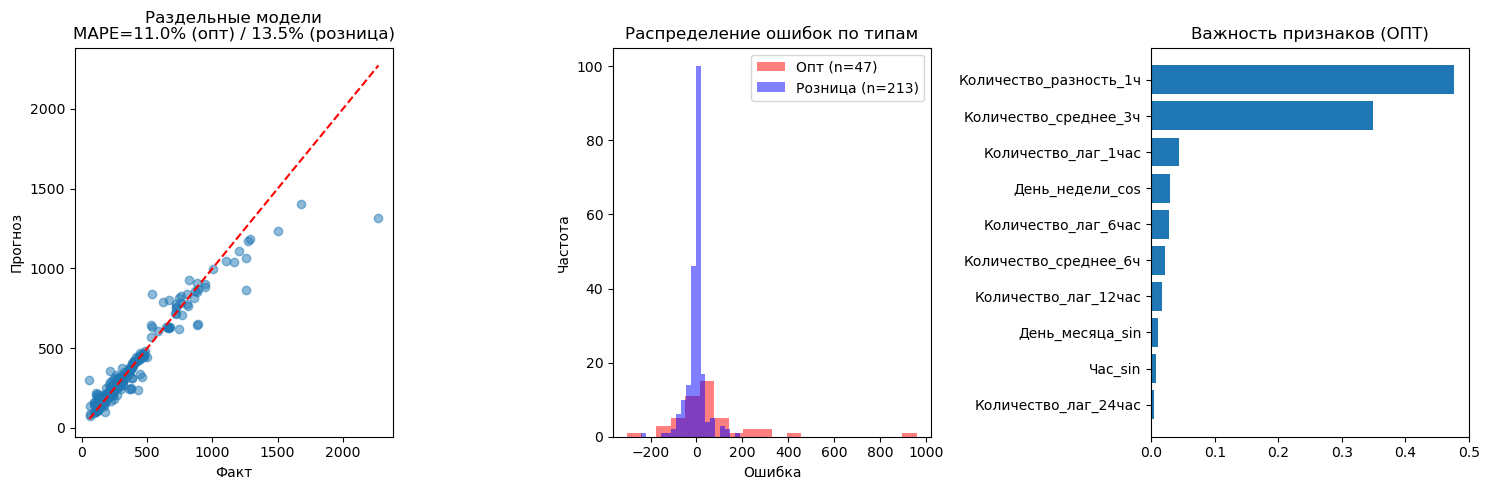

In [69]:
plt.figure(figsize=(15, 5))

# 1. Сравнение моделей
plt.subplot(1, 3, 1)

# Используем предсказания от раздельных моделей
# Собираем все предсказания в один массив
y_pred_combined = np.concatenate([y_opt_pred, y_roz_pred])
y_test_combined = np.concatenate([y_opt_test, y_roz_test])

plt.scatter(y_test_combined, y_pred_combined, alpha=0.5, label='Раздельные модели')
plt.plot([y_test_combined.min(), y_test_combined.max()], 
         [y_test_combined.min(), y_test_combined.max()], 'r--')
plt.xlabel('Факт')
plt.ylabel('Прогноз')
plt.title(f'Раздельные модели\nMAPE={mape_opt:.1f}% (опт) / {mape_roz:.1f}% (розница)')

# 2. Ошибки по типам
plt.subplot(1, 3, 2)

# Опт
errors_opt = y_opt_test - y_opt_pred
plt.hist(errors_opt, alpha=0.5, label=f'Опт (n={len(y_opt_pred)})', bins=20, color='red')
print(f"Опт: {len(y_opt_pred)} записей")

# Розница
errors_roz = y_roz_test - y_roz_pred
plt.hist(errors_roz, alpha=0.5, label=f'Розница (n={len(y_roz_pred)})', bins=20, color='blue')
print(f"Розница: {len(y_roz_pred)} записей")

plt.xlabel('Ошибка')
plt.ylabel('Частота')
plt.legend()
plt.title('Распределение ошибок по типам')

# 3. Важность признаков для опта
plt.subplot(1, 3, 3)
importance_opt = pd.DataFrame({
    'feature': feature_cols,  # используем feature_cols (признаки для опта)
    'importance': model_opt.feature_importances_
}).sort_values('importance', ascending=True).tail(10)
plt.barh(importance_opt['feature'], importance_opt['importance'])
plt.title('Важность признаков (ОПТ)')

plt.tight_layout()
plt.show()

In [70]:
df_features.head()

,Час_начало,Количество,Цена,Сумма,НДС,Организация,Контрагент,Дата,Год,Месяц,...,Количество_среднее_3ч,Количество_среднее_6ч,Количество_среднее_12ч,Количество_среднее_24ч,Количество_разность_1ч,Количество_среднее_24ч_виз,Тип_дня,тип_опт,тип_розница,тип_мелкая_розница
0,2022-11-11 15:00:00,1808.0,148.03,133820.93,22303.49,"ООО ""ВоронежАгро-М""",Лента ООО РЦ Ростов,2022-11-11 15:00:00,2022,11,...,NaN,NaN,NaN,NaN,NaN,NaN,Будний,1,0,0
1,2022-11-11 18:00:00,1632.0,148.03,120794.11,20132.35,"ООО ""ВоронежАгро-М""",Лента ООО РЦ Валищево,2022-11-11 18:00:00,2022,11,...,1808.000000,1808.000000,1808.000000,1808.000000,-176.0,NaN,Будний,1,0,0
2,2022-11-11 23:00:00,3440.0,123.36,212179.20,35363.20,"ООО ""7 Утра""",ВРА-М ООО,2022-11-11 23:00:00,2022,11,...,1720.000000,1720.000000,1720.000000,1720.000000,1808.0,NaN,Будний,1,0,0
3,2022-11-14 17:00:00,2256.0,148.03,166980.10,27830.02,"ООО ""ВоронежАгро-М""",Лента ООО РЦ Тольятти,2022-11-14 17:00:00,2022,11,...,2293.333333,2293.333333,2293.333333,2293.333333,-1184.0,NaN,Будний,1,0,0
4,2022-11-14 23:00:00,2256.0,123.36,139150.08,23191.68,"ООО ""7 Утра""",ВРА-М ООО,2022-11-14 23:00:00,2022,11,...,2442.666667,2284.000000,2284.000000,2284.000000,0.0,NaN,Будний,1,0,0


In [72]:
class SalesForecaster:
    def __init__(self, model_opt, model_roz, feature_cols):
        self.model_opt = model_opt
        self.model_roz = model_roz
        self.feature_cols = feature_cols
        self.last_known = None
        
    def update_last_known(self, df):
        """Обновляет последние известные данные"""
        self.last_known = df.tail(168).copy()  # последняя неделя
        
    def _predict_row(self, row):
        """Внутренняя функция для предсказания одной строки"""
        X_row = pd.DataFrame([row])[self.feature_cols]
        if row['тип_опт'] == 1:
            return self.model_opt.predict(X_row)[0]
        else:
            return self.model_roz.predict(X_row)[0]
    
    def forecast(self, start_date, days=7):
        """Прогноз на указанный период"""
        
        if self.last_known is None:
            raise ValueError("Сначала вызовите update_last_known()")
        
        print(f"Создаем прогноз на {days} дней с {start_date.date()}...")
        
        # Создаем данные для прогноза
        forecast_data = []
        
        # Берем шаблон из последней известной записи
        template = self.last_known.iloc[-1:].copy()
        
        for day in range(days):
            current_date = start_date + timedelta(days=day)
            
            # Для каждой организации
            for org in self.last_known['Организация'].unique():
                # Для каждого часа работы
                for hour in [8, 11, 14, 17, 20]:
                    # Создаем запись на основе шаблона
                    record = template.iloc[0].to_dict()
                    record['Дата'] = current_date + timedelta(hours=hour)
                    record['Организация'] = org
                    
                    # Обновляем временные признаки
                    record['Месяц'] = current_date.month
                    record['Час'] = hour
                    record['День_недели'] = current_date.weekday()
                    
                    # Циклические признаки
                    record['Месяц_sin'] = np.sin(2 * np.pi * current_date.month / 12)
                    record['Месяц_cos'] = np.cos(2 * np.pi * current_date.month / 12)
                    record['Час_sin'] = np.sin(2 * np.pi * hour / 24)
                    record['Час_cos'] = np.cos(2 * np.pi * hour / 24)
                    
                    # Определяем тип продажи (по организации)
                    record['тип_опт'] = 1 if 'Опт' in org else 0
                    
                    forecast_data.append(record)
        
        # Создаем DataFrame
        forecast_df = pd.DataFrame(forecast_data)
        
        # Делаем прогноз для каждой строки
        print(f"   Вычисляем прогноз для {len(forecast_df)} записей...")
        predictions = []
        for _, row in forecast_df.iterrows():
            pred = self._predict_row(row)
            predictions.append(pred)
        
        forecast_df['Прогноз'] = predictions
        
        return forecast_df

# Использование
forecaster = SalesForecaster(model_opt, model_roz, feature_cols)
forecaster.update_last_known(df_features)

# Прогноз на неделю
next_week = datetime.now() + timedelta(days=1)
weekly_forecast = forecaster.forecast(next_week, days=7)

# Результаты
print(f"\nПрогноз на неделю с {next_week.date()}:")
daily = weekly_forecast.groupby(weekly_forecast['Дата'].dt.date)['Прогноз'].sum()
print(daily)
print(f"\nВсего за неделю: {daily.sum():.0f} единиц")

# Сохраняем прогноз
if 'weekly_forecast' in locals() or 'weekly_forecast' in globals():
    
    # Вариант 1: Сохраняем как CSV через save_to_minio
    save_to_minio(
        bucket_name="sales-analytics",
        block_name="творог_365_дней_прогнозы",
        data=weekly_forecast,  # сохраняем как CSV
        plot_name=f"прогноз_неделя_{next_week.date()}",  # для имени файла
        formats=['csv'],  # только CSV
        excel_data=None
    )

Создаем прогноз на 7 дней с 2026-03-11...
   Вычисляем прогноз для 70 записей...

Прогноз на неделю с 2026-03-11:
Дата
2026-03-11     960.045471
2026-03-12    4812.729492
2026-03-13    4812.729492
2026-03-14    4812.729492
2026-03-15    4812.729492
2026-03-16    4812.729492
2026-03-17    4812.729492
2026-03-18    3852.684082
Name: Прогноз, dtype: float32

Всего за неделю: 33689 единиц

 Сохраняем в Minio: sales-analytics/творог_365_дней_прогнозы
 CSV: http://localhost:9003/sales-analytics/2026-03-10/творог_365_дней_прогнозы/прогноз_неделя_2026-03-11.csv
    Всего сохранено: 1 объектов


In [73]:
# Создаем daily_forecast из weekly_forecast
daily_forecast = weekly_forecast.groupby(weekly_forecast['Дата'].dt.date)['Прогноз'].sum().reset_index()
daily_forecast.columns = ['Дата', 'Прогноз_количество']
daily_forecast['Дата'] = pd.to_datetime(daily_forecast['Дата']).dt.strftime('%Y-%m-%d')

print("ЕЖЕДНЕВНЫЙ ПРОГНОЗ:")
print(daily_forecast)

# Создаем полный отчет
final_report = pd.DataFrame({
    'Дата': daily_forecast['Дата'],
    'Прогноз_продаж': daily_forecast['Прогноз_количество'].round(0).astype(int),
    'Тип': 'ежедневный'
})

# Добавляем итог
total_row = pd.DataFrame({
    'Дата': ['ИТОГО ЗА НЕДЕЛЮ'],
    'Прогноз_продаж': [int(daily_forecast['Прогноз_количество'].sum())],
    'Тип': ['итог']
})
final_report = pd.concat([final_report, total_row], ignore_index=True)

print("\nИТОГОВЫЙ ОТЧЕТ:")
print(final_report)

# Сохраняем отчет в Minio
save_to_minio(
    bucket_name="sales-analytics",
    block_name="творог_365_дней_отчеты",
    data=final_report,
    plot_name=f"еженедельный_отчет_{datetime.now().strftime('%Y%m%d')}",
    formats=['csv'],  # только CSV
    excel_data=None
)

# Сохраняем данные для модели в Minio
save_to_minio(
    bucket_name="ml-datasets",
    block_name="творог_365_дней_признаки",
    data=df_features,
    plot_name=f"признаки_модели_{datetime.now().strftime('%Y%m%d')}",
    formats=['csv'],
    excel_data=None
)

print(f"\n Отчеты сохранены в Minio (sales-analytics и ml-datasets)")

ЕЖЕДНЕВНЫЙ ПРОГНОЗ:
         Дата  Прогноз_количество
0  2026-03-11          960.045471
1  2026-03-12         4812.729492
2  2026-03-13         4812.729492
3  2026-03-14         4812.729492
4  2026-03-15         4812.729492
5  2026-03-16         4812.729492
6  2026-03-17         4812.729492
7  2026-03-18         3852.684082

ИТОГОВЫЙ ОТЧЕТ:
              Дата  Прогноз_продаж         Тип
0       2026-03-11             960  ежедневный
1       2026-03-12            4813  ежедневный
2       2026-03-13            4813  ежедневный
3       2026-03-14            4813  ежедневный
4       2026-03-15            4813  ежедневный
5       2026-03-16            4813  ежедневный
6       2026-03-17            4813  ежедневный
7       2026-03-18            3853  ежедневный
8  ИТОГО ЗА НЕДЕЛЮ           33689        итог

 Сохраняем в Minio: sales-analytics/творог_365_дней_отчеты
 CSV: http://localhost:9003/sales-analytics/2026-03-10/творог_365_дней_отчеты/еженедельный_отчет_20260310.csv
    Всего сохране